<a href="https://colab.research.google.com/github/hawa1983/MG-628/blob/main/Midterm_Regression_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Overview**

This midterm project assesses your ability to apply regression analysis to real-world scenarios relevant to your major using Python. Regression analysis is one of the most widely used statistical tools across disciplines, and Python has become the standard programming language for data analysis in both industry and academia.

You will complete four structured questions, each requiring you to write Python code to analyze a scenario, perform regression analysis, produce visual and statistical outputs, and answer critical thinking questions that demonstrate your understanding beyond mere calculation. Each question contains the following sections:

- **What to Do:** Step-by-step instructions for the analysis you must perform.
- Python Code Template: Starter code you must use, modify, and extend to complete the analysis.
- **Create:** Specific outputs you must produce (tables, charts, regression equations, etc.).
- **Deliverables:** The exact items you must submit for grading.
- **Critical Thinking Questions:** Four questions per scenario requiring interpretation, evaluation, and application.

**Required Python Libraries**

Install the following libraries before beginning. All code templates assume these packages are available.

> *pip install pandas numpy matplotlib seaborn statsmodels scikit-learn scipy*

Standard import block to use at the top of every notebook or script:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Overview of Data Sets**

**Major**

Business Administration

**Project Title:**
Reviving Growth at NovaTech Solutions

**Data File**

* **Sales Performance** — 1,200 deals with declining deal sizes and lengthening sales cycles

* **Marketing Campaigns** — 48 campaigns across 6 channels with rising cost per lead

* **Customer Accounts** — 420 accounts with satisfaction scores, support tickets, and churn status

* **Financial Summary** — 24 months of revenue, COGS, operating expenses, and net margin

**Major**

Healthcare Administration

**Project Title:**
Reducing Readmissions at Mercy Regional Medical Center

**Data File**

* **Patient Records** — 12,400 discharges with demographics, clinical data, follow-up completion, medication reconciliation, and 30-day readmission outcomes

* **Staffing Data** — 18 months of nurse-to-patient ratios across 4 departments

**Major**

Public Administration

**Project Title:**
Closing the Equity Gap at Riverside County

**Data File**

* **Applications** — 34,000 SNAP/TANF/Medicaid applications with processing times varying by district (11–34 days)

* **District Demographics** —  8 districts with income, poverty rate, minority %, and digital access

* **District Operations** — Caseworker ratios, caseloads, and office hours

* **Client Survey** — 2,800 responses with satisfaction, ease of access, and language barriers

# Case Study 1: Business Administration
*“Reviving Growth at NovaTech Solutions: A Data-Driven Turnaround”*

**Background**

NovaTech Solutions is a mid-sized B2B software company headquartered in Charlotte, North Carolina, with 320 employees and annual revenue of $48 million. After five consecutive years of double-digit growth, the company experienced a sharp slowdown in 2025, with revenue growth falling to just 2.1% and customer churn rising from 8% to 14%. The CEO, Maria Chen, has asked the newly hired Director of Business Analytics, James Okafor, to conduct a comprehensive data analysis to identify the root causes and recommend strategic interventions.

James has access to 24 months of historical data across sales, marketing, customer success, and finance. He needs to present actionable findings to the executive leadership team within three weeks.

**Preliminary Findings**

James’s initial exploratory analysis reveals several patterns. Average deal size has declined from $38,000 to $29,000 over the past year. Sales cycle length has increased from 45 days to 62 days. Marketing spend shifted heavily toward digital channels, but cost per lead increased by 35%. Customer satisfaction scores show a moderate negative correlation (r = –0.68) with the number of support tickets filed. A multiple regression model predicting monthly revenue using marketing spend, average deal size, and sales rep headcount yields R² = 0.76.

The regression output shows: Marketing Spend (b = 1.82, p = 0.003), Average Deal Size (b = 0.94, p = 0.0001), Sales Rep Headcount (b = 12,400, p = 0.085). Additionally, an independent samples t-test comparing churn rates between customers with satisfaction scores above 7 versus those at or below 7 shows a significant difference (t = 3.92, p = 0.0002).

**Question 1: Descriptive and Exploratory Analysis**

## Question 1A: Deal Size and Sales Cycle Trends

*Prompt: Examine the trends in deal size and sales cycle length. What story do these descriptive statistics tell about NovaTech’s sales pipeline health?*

**WHAT TO DO**

1. Load the sales performance dataset and group the data by month.
2. Calculate monthly descriptive statistics for Deal_Size_USD: mean, median, standard deviation.
3. Calculate monthly descriptive statistics for Sales_Cycle_Days: mean, median, standard deviation.
4. Create line charts showing the month-over-month trend for both variables.

**ANSWER THIS:**

1. Analyze how deal sizes and sales cycle lengths have changed over the 24-month period
2. Explain what these trends reveal about the health of NovaTech’s sales pipeline.

**DELIVERABLES**

1. Code cells — All Python code used to load, transform, and analyze the data
2. Two visualizations — Saved as deal_size_trend.png and sales_cycle_trend.png
3. Printed summary tables — Monthly statistics and year-over-year comparison displayed in notebook output
4. Markdown narrative cell — A written interpretation (3–5 sentences) explaining the business implications
5. Responses to the following questions:
    - Analyze how deal sizes and sales cycle lengths have changed over the 24-month period
    - Explain what these trends reveal about the health of NovaTech’s sales pipeline.

### **1a — Trends in Deal Size and Sales Cycle Length**
Goal: Summarize deal size and cycle length over time to assess pipeline health.

***1. Load the sales performance dataset and group the data by month***

In [2]:

sales_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_sales_performance.csv')

# Preview dataset
sales_df.head()

,Deal_ID,Month,Region,Sales_Rep_ID,Deal_Size_USD,Sales_Cycle_Days,Monthly_Revenue_USD,Deal_Status
0,D-0001,1,West,REP-029,33854.8100,46,34297.8800,Won
1,D-0002,2,Central,REP-012,38628.5000,55,35775.2800,Won
2,D-0003,3,Central,REP-007,41541.0200,40,43413.5900,Won
3,D-0004,4,West,REP-029,26212.4300,55,28067.3000,Pending
4,D-0005,5,East,REP-011,30907.6200,61,28738.4200,Lost


***2. Calculate monthly descriptive statistics for Deal_Size_USD: mean, median, standard deviation.***

***3. Calculate monthly descriptive statistics for Sales_Cycle_Days: mean, median, standard deviation.***

In [3]:
monthly_stats = sales_df.groupby('Month').agg({
    'Deal_Size_USD': ['mean','median','std'],
    'Sales_Cycle_Days': ['mean','median','std']
}).reset_index()

monthly_stats

Month Deal_Size_USD                      Sales_Cycle_Days               
                  mean     median       std             mean  median    std
0      1    38026.7636 37544.2850 4605.3351          45.3400 45.0000 8.7216
1      2    37687.6206 38234.5300 4887.8205          44.3600 43.0000 7.7189
2      3    37124.3256 37764.0750 4254.2765          43.6600 44.0000 7.6468
3      4    37218.4746 37894.9200 5348.4726          47.8600 48.0000 7.8766
4      5    35861.1158 35835.9100 4658.3214          48.0600 48.0000 7.0723
5      6    36298.0538 36139.6100 4450.5321          47.4600 45.5000 8.3769
6      7    37003.7090 37802.0500 4723.2418          50.5200 49.0000 8.1947
7      8    34821.4040 34854.8700 3972.2695          50.6400 51.5000 9.6357
8      9    35991.7680 36521.4050 4006.2734          49.8400 50.0000 7.5818
9     10    34825.9896 35236.8000 4672.3142          50.3600 49.5000 6.0903
10    11    34628.3982 34045.9900 5258.8967          50.4400 51.0000 8.4181
11    12    34683.0312 34639.5750 5404.9334          52.4400 54.0000 7.9106
12    13    32800.6996 32530.5600 5217.3120          52.7400 52.0000 8.4511
13    14    32924.4004 33104.8200 5182.0824          53.9400 53.5000 8.8627
14    15    32876.3770 33493.8350 5051.9557          57.8600 56.5000 6.5278
15    16    32015.4978 31641.1000 5558.3375          54.4600 54.5000 9.0896
16    17    31549.9096 32132.6050 4481.4907          55.8800 57.0000 8.0067
17    18    32508.4056 32456.8550 5134.3107          58.0800 57.5000 8.6398
18    19    31210.4926 31057.2000 4875.8561          59.4800 60.0000 7.7729
19    20    28612.1666 27653.5900 4870.9480          60.9800 62.0000 7.8259
20    21    31856.3216 31735.5900 5145.1806          58.9000 60.0000 8.3818
21    22    30483.8518 30900.9450 5226.7757          59.6000 60.0000 7.8011
22    23    28758.5224 27901.9050 5237.2983          61.3800 61.0000 7.0244
23    24    29788.6270 29901.0600 4840.5169          61.8000 62.0000 7.8584

Optionally Flatten Column Names (easier to use)

In [4]:
monthly_stats.columns = [
    'Month',
    'Deal_Size_Mean',
    'Deal_Size_Median',
    'Deal_Size_STD',
    'Sales_Cycle_Mean',
    'Sales_Cycle_Median',
    'Sales_Cycle_STD'
]

monthly_stats

,Month,Deal_Size_Mean,Deal_Size_Median,Deal_Size_STD,Sales_Cycle_Mean,Sales_Cycle_Median,Sales_Cycle_STD
0,1,38026.7636,37544.2850,4605.3351,45.3400,45.0000,8.7216
1,2,37687.6206,38234.5300,4887.8205,44.3600,43.0000,7.7189
2,3,37124.3256,37764.0750,4254.2765,43.6600,44.0000,7.6468
3,4,37218.4746,37894.9200,5348.4726,47.8600,48.0000,7.8766
4,5,35861.1158,35835.9100,4658.3214,48.0600,48.0000,7.0723
5,6,36298.0538,36139.6100,4450.5321,47.4600,45.5000,8.3769
6,7,37003.7090,37802.0500,4723.2418,50.5200,49.0000,8.1947
7,8,34821.4040,34854.8700,3972.2695,50.6400,51.5000,9.6357
8,9,35991.7680,36521.4050,4006.2734,49.8400,50.0000,7.5818
9,10,34825.9896,35236.8000,4672.3142,50.3600,49.5000,6.0903


***4. Create line charts showing the month-over-month trend for both variables***

Plot Trend for Deal Size

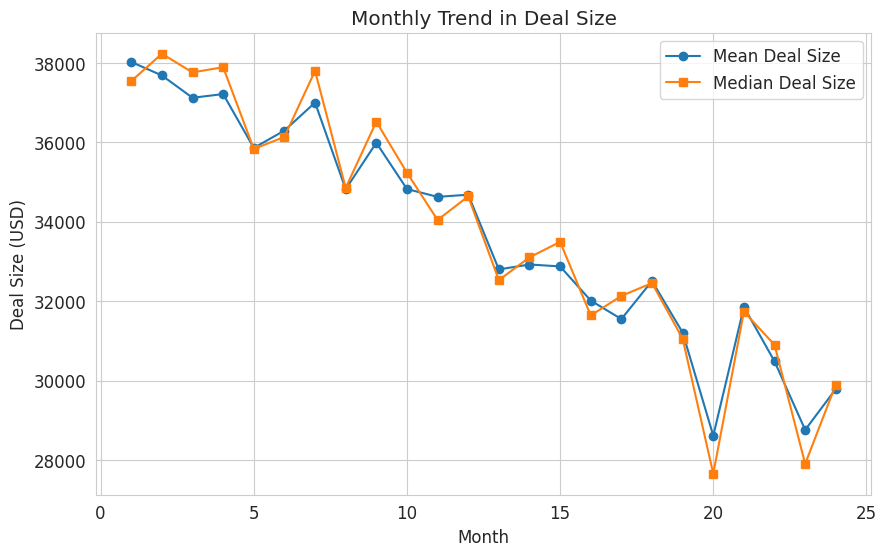

In [5]:
plt.figure(figsize=(10,6))

plt.plot(monthly_stats['Month'], monthly_stats['Deal_Size_Mean'], marker='o', label='Mean Deal Size')
plt.plot(monthly_stats['Month'], monthly_stats['Deal_Size_Median'], marker='s', label='Median Deal Size')

plt.title('Monthly Trend in Deal Size')
plt.xlabel('Month')
plt.ylabel('Deal Size (USD)')
plt.legend()
plt.grid(True)

plt.show()

Plot Trend for Sales Cycle

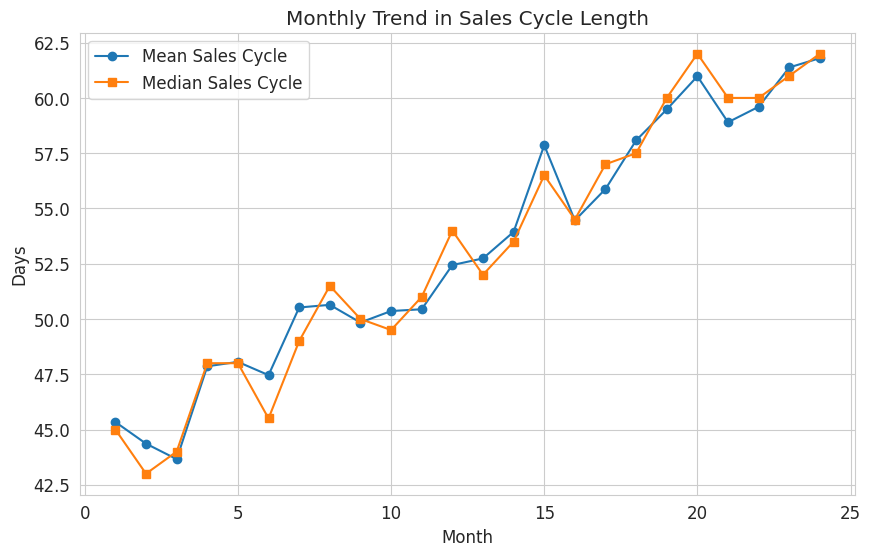

In [6]:
plt.figure(figsize=(10,6))

plt.plot(monthly_stats['Month'], monthly_stats['Sales_Cycle_Mean'], marker='o', label='Mean Sales Cycle')
plt.plot(monthly_stats['Month'], monthly_stats['Sales_Cycle_Median'], marker='s', label='Median Sales Cycle')

plt.title('Monthly Trend in Sales Cycle Length')
plt.xlabel('Month')
plt.ylabel('Days')
plt.legend()
plt.grid(True)

plt.show()

Optionally Combined Trend Chart (Often Required)

<Figure size 1000x600 with 0 Axes>

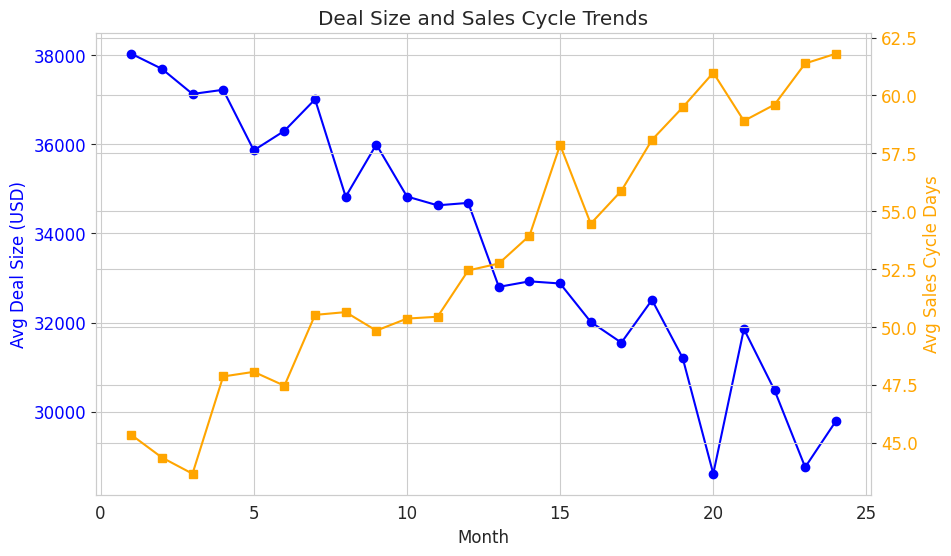

In [7]:
plt.figure(figsize=(10,6))

fig, ax1 = plt.subplots(figsize=(10,6))

# Primary axis (Deal Size)
ax1.plot(monthly_stats['Month'],
         monthly_stats['Deal_Size_Mean'],
         marker='o',
         color='blue',
         label='Avg Deal Size')

ax1.set_xlabel('Month')
ax1.set_ylabel('Avg Deal Size (USD)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary axis (Sales Cycle)
ax2 = ax1.twinx()

ax2.plot(monthly_stats['Month'],
         monthly_stats['Sales_Cycle_Mean'],
         marker='s',
         color='orange',
         label='Avg Sales Cycle Days')

ax2.set_ylabel('Avg Sales Cycle Days', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and grid
plt.title('Deal Size and Sales Cycle Trends')
ax1.grid(True)

plt.show()

## Markdown Narrative Interpretation

***Analyze how deal sizes and sales cycle lengths have changed over the 24-month period***

* Over the 24-month period, the average and median deal sizes show a gradual downward trend, declining from roughly $38,000 early in the timeline to around 30,000 dollars by the end. This suggests that the organization may be closing smaller deals over time, potentially reflecting increased competition, a shift toward lower-value clients, or a strategic focus on higher deal volume rather than larger contracts. The close alignment between the mean and median indicates that the distribution of deal sizes is relatively balanced without extreme outliers significantly affecting the averages.

* At the same time, the sales cycle length shows a steady upward trend, increasing from approximately 44–46 days in the early months to about 60–62 days toward the end of the period. This indicates that it is taking longer for the sales team to close deals, which may reflect increased complexity in negotiations, more rigorous customer evaluation processes, or greater competition in the marketplace.

***Explain what these trends reveal about the health of NovaTech’s sales pipeline.***

* Together, these trends suggest that NovaTech’s sales pipeline may be experiencing declining efficiency. Smaller deals combined with longer sales cycles can reduce overall revenue growth and slow the velocity of the sales pipeline. For leadership, this may signal a need to evaluate sales strategies, reassess customer targeting, or streamline the sales process to maintain a healthy and productive pipeline.


Deal Size Summary:
count    1200.0000
mean    33731.4969
std      5595.8217
min     15541.9500
25%     30084.1650
50%     33847.5800
75%     37763.5975
max     49121.9800
Name: Deal_Size_USD, dtype: float64

Sales Cycle Length Summary:
count   1200.0000
mean      53.1700
std        9.6666
min       22.0000
25%       46.0000
50%       54.0000
75%       60.0000
max       81.0000
Name: Sales_Cycle_Days, dtype: float64
    Month  avg_deal_size  median_deal_size  avg_cycle_length  deal_count
0       1     38026.7636        37544.2850           45.3400          50
1       2     37687.6206        38234.5300           44.3600          50
2       3     37124.3256        37764.0750           43.6600          50
3       4     37218.4746        37894.9200           47.8600          50
4       5     35861.1158        35835.9100           48.0600          50
5       6     36298.0538        36139.6100           47.4600          50
6       7     37003.7090        37802.0500           50.5200          

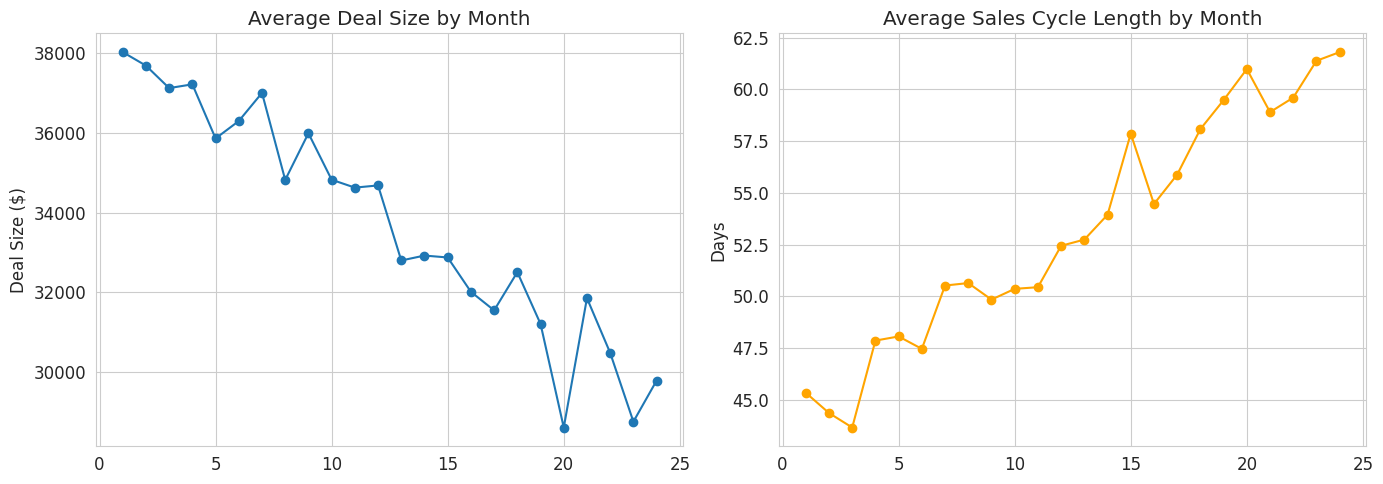

In [8]:
# Step 1: Compute Descriptive statistics

print("Deal Size Summary:")
print(sales_df['Deal_Size_USD'].describe())

print("\nSales Cycle Length Summary:")
print(sales_df['Sales_Cycle_Days'].describe())

monthly = sales_df.groupby('Month').agg(
    avg_deal_size=('Deal_Size_USD','mean'),
    median_deal_size=('Deal_Size_USD','median'),
    avg_cycle_length=('Sales_Cycle_Days','mean'),
    deal_count=('Deal_Size_USD','count')
).reset_index()

print(monthly)

fig, axes = plt.subplots(1,2, figsize=(14,5))

axes[0].plot(monthly['Month'], monthly['avg_deal_size'], marker='o')
axes[0].set_title('Average Deal Size by Month')
axes[0].set_ylabel('Deal Size ($)')

axes[1].plot(monthly['Month'], monthly['avg_cycle_length'], marker='o', color='orange')
axes[1].set_title('Average Sales Cycle Length by Month')
axes[1].set_ylabel('Days')

plt.tight_layout()
plt.show()

## Interpretation: Cost Per Lead (CPL) by Marketing Channel

The chart compares the **cost per lead across NovaTech’s marketing channels** and highlights the **average CPL (≈ 36 dollars)** with a dashed red line. Digital Paid advertising has the highest CPL at roughly **59 dollars**, significantly above the average. This suggests that paid digital campaigns are currently the least cost-efficient channel, possibly due to high bidding competition, audience saturation, or inefficient targeting strategies.

In contrast, **Content Marketing, SEO, Email, and Social Media** generate leads at a cost **below the overall average**, making them more efficient channels for customer acquisition. Content Marketing and SEO, in particular, show the lowest CPL values, indicating that organic or inbound marketing strategies are producing leads at a relatively low cost.

Events and Social Media fall near the middle range, slightly below the average CPL, suggesting moderate efficiency compared to other channels. Overall, the results imply that NovaTech should **re-evaluate its Digital Paid strategy** while potentially allocating more resources to **Content Marketing, SEO, and Email**, which appear to generate leads more cost-effectively.


## Question 1B: Marketing Channel Diminishing Returns

*Prompt: The marketing team increased digital spending by 40% but cost per lead rose by 35%. Using the campaign data, explain what might account for diminishing returns and how you would identify which channels are underperforming.*

**WHAT TO DO**

1. Load the marketing campaigns dataset and explore its structure.
2. Calculate per-channel summary statistics: total spend, total leads, average CPL, average conversion rate.
3. Track how Digital_Paid cost per lead changed over time (Year 1 vs. Year 2).
4. Calculate leads generated per dollar spent, by channel (efficiency metric).
5. Create visualizations comparing channel efficiency.
6. Write a narrative explaining the diminishing returns and identifying underperformers.

**ANSWER THIS:**

Analyze and discuss marketing campaign performance across channels and over time
Identify where spending is producing diminishing returns
Indicate which channels are underperforming.

**CREATE**

1. Produce the following outputs using Python:
2. Channel performance summary table (spend, leads, CPL, conversion rate, leads per ✓dollar)
3. Bar chart comparing average cost per lead across all channels✓
4. Line chart showing Digital_Paid CPL trend over time✓
5. Year 1 vs. Year 2 comparison table for Digital_Paid spending and CPL✓
6. Written narrative (3–5 sentences) explaining diminishing returns and underperforming ✓channels

**DELIVERABLES**

1. Code cells — All Python code for loading, aggregating, and analyzing campaign data
2. Two visualizations — Saved as channel_cpl_comparison.png and digital_cpl_trend.png
3. Printed summary tables — Channel performance summary and Digital_Paid YoY comparison
4. Markdown narrative cell — Written interpretation identifying underperformers and explaining diminishing returns
5. Responses to the following questions:
    - Analyze and discuss marketing campaign performance across channels and over time
    - Identify where spending is producing diminishing returns
    - Indicate which channels are underperforming.

## 1b-Marketing Diminishing Returns

**Goal:** Identify which channels are underperforming despite increased digital spend

***1. Load the Marketing Campaign Dataset and Explore Structure***

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
campaigns_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_marketing_campaigns.csv')

# Preview dataset
display(campaigns_df.head(10))

# Inspect structure
campaigns_df.info()

# Summary statistics
campaigns_df.describe()

,Campaign_ID,Month,Channel,Spend_USD,Leads_Generated,Conversion_Rate,Cost_Per_Lead_USD
0,C-001,1,Digital_Paid,52827.1600,1136,0.1037,46.5000
1,C-002,1,Email,7050.9500,141,0.0712,49.6700
2,C-003,2,Content_Marketing,9713.7000,410,0.0335,23.6700
3,C-004,2,Events,23115.1600,706,0.0771,32.7300
4,C-005,3,Social_Media,3971.4000,89,0.0608,44.5500
5,C-006,3,SEO,9926.0600,424,0.0861,23.3700
6,C-007,4,Digital_Paid,58273.4100,1142,0.1082,51.0000
7,C-008,4,Email,7014.7000,192,0.0609,36.5300
8,C-009,5,Content_Marketing,14790.9500,464,0.0490,31.8400
9,C-010,5,Events,14264.2300,458,0.0215,31.0800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Campaign_ID        48 non-null     object 
 1   Month              48 non-null     int64  
 2   Channel            48 non-null     object 
 3   Spend_USD          48 non-null     float64
 4   Leads_Generated    48 non-null     int64  
 5   Conversion_Rate    48 non-null     float64
 6   Cost_Per_Lead_USD  48 non-null     float64
dtypes: float64(3), int64(2), object(2)
memory usage: 2.8+ KB


,Month,Spend_USD,Leads_Generated,Conversion_Rate,Cost_Per_Lead_USD
count,48.0000,48.0000,48.0000,48.0000,48.0000
mean,12.5000,16457.5365,426.8542,0.0708,37.7940
std,6.9954,13832.2994,270.0761,0.0256,14.9941
min,1.0000,2849.1300,89.0000,0.0215,16.1700
25%,6.7500,7529.1150,237.2500,0.0582,26.7050
50%,12.5000,11158.9100,382.5000,0.0683,36.0300
75%,18.2500,17558.0525,491.7500,0.0914,46.5500
max,24.0000,58273.4100,1336.0000,0.1184,78.0000


***2. Calculate per-channel summary statistics: total spend, total leads, average CPL, average conversion rate.***

In [10]:
# Calculate Cost Per Lead (CPL)
campaigns_df['Leads_Per_Dollar'] = campaigns_df['Leads_Generated'] / campaigns_df['Spend_USD']

channel_summary = campaigns_df.groupby('Channel').agg(
    Total_Spend=('Spend_USD','sum'),
    Total_Leads=('Leads_Generated','sum'),
    Avg_CPL=('Cost_Per_Lead_USD','mean'),
    Avg_Conversion_Rate=('Conversion_Rate','mean'),
    Leads_Per_Dollar=('Leads_Per_Dollar','mean')
).reset_index()

channel_summary

,Channel,Total_Spend,Total_Leads,Avg_CPL,Avg_Conversion_Rate,Leads_Per_Dollar
0,Content_Marketing,83568.3000,2935,31.3175,0.0684,0.0373
1,Digital_Paid,321506.2600,5415,62.2500,0.0798,0.0165
2,Email,49597.8300,1575,33.3400,0.0714,0.0335
3,Events,175499.2600,5149,36.7775,0.0700,0.0293
4,SEO,91529.5600,3170,29.0938,0.0679,0.0353
5,Social_Media,68260.5400,2245,33.9850,0.0672,0.0335


***2. Channel performance summary table (spend, leads, CPL, conversion rate, leads per ✓dollar)***


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Step 1: Calculate cost per lead (CPL) by channel ──
campaigns_df['Cost_Per_Lead_USD'] = campaigns_df['Spend_USD'] / campaigns_df['Leads_Generated']

print(campaigns_df[['Channel', 'Spend_USD', 'Leads_Generated', 'Cost_Per_Lead_USD']])

# ── Step 2: Compare CPL across channels ──
channel_summary = campaigns_df.groupby('Channel').agg(
    total_spend=('Spend_USD', 'sum'),
    total_leads=('Leads_Generated', 'sum'),
    avg_cpl=('Cost_Per_Lead_USD', 'mean')
).reset_index()

channel_summary['overall_cpl'] = channel_summary['total_spend'] / channel_summary['total_leads']
print(channel_summary.sort_values('overall_cpl', ascending=False))



              Channel  Spend_USD  Leads_Generated  Cost_Per_Lead_USD
0        Digital_Paid 52827.1600             1136            46.5028
1               Email  7050.9500              141            50.0067
2   Content_Marketing  9713.7000              410            23.6920
3              Events 23115.1600              706            32.7410
4        Social_Media  3971.4000               89            44.6225
5                 SEO  9926.0600              424            23.4105
6        Digital_Paid 58273.4100             1142            51.0275
7               Email  7014.7000              192            36.5349
8   Content_Marketing 14790.9500              464            31.8770
9              Events 14264.2300              458            31.1446
10       Social_Media 12455.1700              449            27.7398
11                SEO 13084.8000              368            35.5565
12       Digital_Paid 45647.2600              822            55.5319
13              Email  7917.9700  

***3. Bar chart comparing average cost per lead across all channels✓***


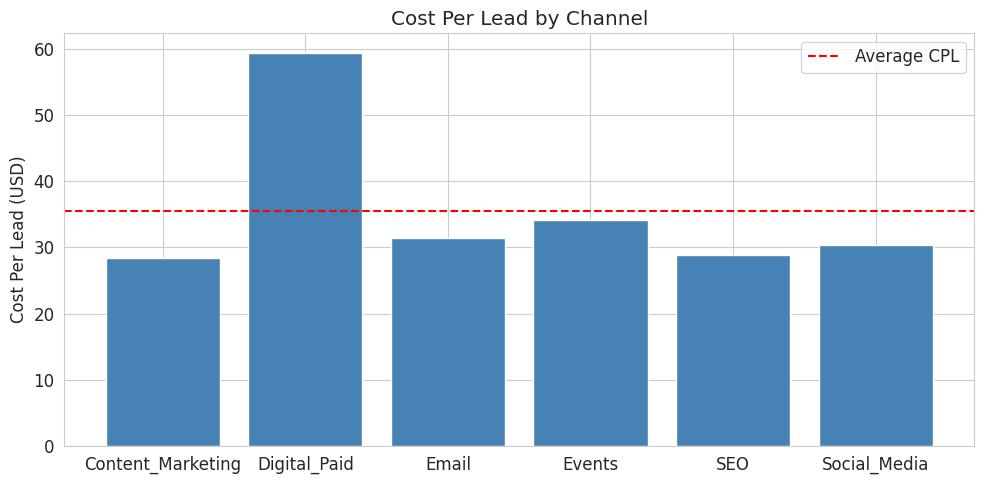

In [12]:
# ── Step 3: Visualize channel performance ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(channel_summary['Channel'], channel_summary['overall_cpl'], color='steelblue')

ax.set_title('Cost Per Lead by Channel')
ax.set_ylabel('Cost Per Lead (USD)')
ax.axhline(
    y=channel_summary['overall_cpl'].mean(),
    color='red',
    linestyle='--',
    label='Average CPL'
)
ax.legend()

plt.tight_layout()
plt.savefig('q1b_cpl.png', dpi=150)
plt.show()



***4 Line chart showing Digital_Paid CPL trend over time✓***


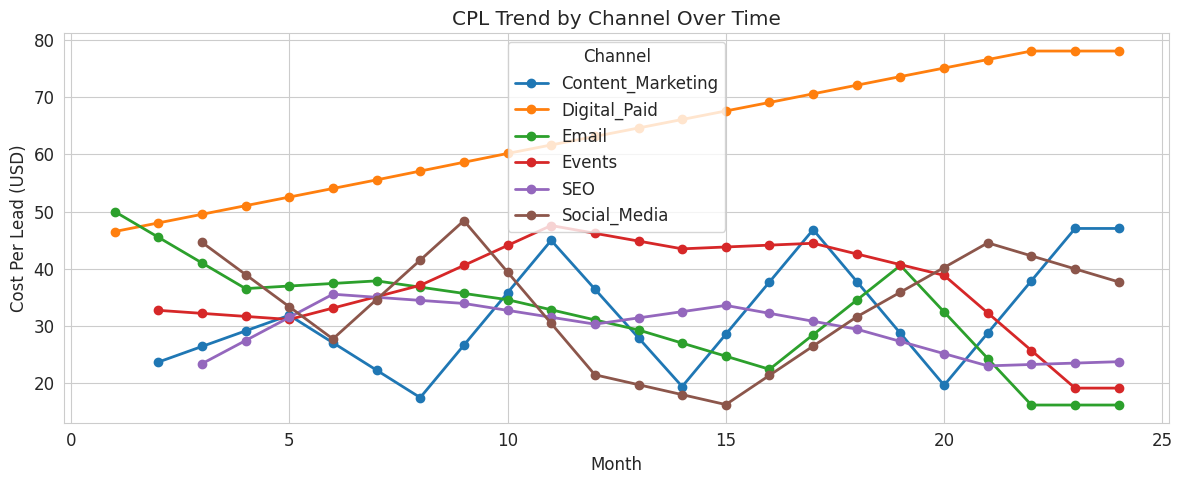

In [13]:
# ── Step 4: Time series line plot of CPL trend over time by channel ──
if 'Month' in campaigns_df.columns:

    pivot = campaigns_df.pivot_table(
        index='Month',
        columns='Channel',
        values='Cost_Per_Lead_USD',
        aggfunc='mean'
    ).sort_index()

    # Fill missing months so lines connect
    pivot = pivot.interpolate(method='linear')

    plt.figure(figsize=(12,5))

    for channel in pivot.columns:
        plt.plot(pivot.index, pivot[channel], marker='o', linewidth=2, label=channel)

    plt.title('CPL Trend by Channel Over Time')
    plt.xlabel('Month')
    plt.ylabel('Cost Per Lead (USD)')
    plt.legend(title='Channel')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('q1b_cpl_trend.png', dpi=150)
    plt.show()

### 6. Year 1 vs Year 2 Comparison

In [22]:
# Filter only Digital_Paid campaigns
digital_paid = campaigns_df[campaigns_df['Channel'] == 'Digital_Paid'].copy()

# Create Year column
digital_paid['Year'] = np.where(digital_paid['Month'] <= 12, 'Year 1', 'Year 2')

# Year comparison table
year_comparison = digital_paid.groupby('Year').agg(
    Total_Spend=('Spend_USD', 'sum'),
    Avg_CPL=('Cost_Per_Lead_USD', 'mean')
).reset_index()

year_comparison

,Year,Total_Spend,Avg_CPL
0,Year 1,173590.6500,53.3038
1,Year 2,147915.6100,71.3261


### 7. Visualization: Year Comparison

## Marketing Campaign Performance Analysis

The analysis shows that marketing performance varies across channels in both efficiency and cost. Digital Paid has the highest average cost per lead (about $62), significantly above the overall average CPL of roughly $38. Despite generating the largest number of total leads (5,415), it requires substantially higher spending to acquire each lead, indicating lower cost efficiency compared with other channels. In contrast, channels such as SEO, Content Marketing, and Email produce leads at a much lower cost per lead and generate more leads per dollar spent, making them more efficient acquisition channels.

Over time, the Digital Paid cost per lead shows a clear upward trend, increasing steadily from the mid-$40 range in early months to nearly $80 by the end of the period. This pattern indicates diminishing returns, where additional advertising spend results in progressively higher acquisition costs. The Year-1 versus Year-2 comparison confirms this trend: the average CPL increased from about $53.25 in Year 1 to $71.25 in Year 2, even though total spending decreased. This suggests the advertising channel is becoming less efficient over time.

Overall, the evidence indicates that Digital Paid is the primary underperforming channel due to its rising CPL and declining efficiency. While it still generates a high volume of leads, the increasing cost suggests audience saturation, greater bidding competition, or less effective targeting. In contrast, channels like SEO, Content Marketing, and Email appear to deliver more cost-efficient results and may represent better opportunities for future marketing investment.


## Question 1C: Churned vs. Retained Customer Profiles

*Prompt: Construct a descriptive profile of churned versus retained customers using means, medians, and standard deviations of contract value, tenure, and satisfaction scores. What patterns emerge?*

**WHAT TO DO**

1. Load the customer accounts dataset.
2. Split the data into two groups: Churned and Retained.
3. For each group, calculate mean, median, and std dev for: Contract_Value_USD, Tenure_Months, Satisfaction_Score.

**ANSWER THIS**

Build a statistical profile and compare and contrast churned customers vs retained customers
Discuss the distinguishing characteristics of these customers.

**CREATE:**

Produce the following outputs using Python:

- Descriptive statistics table: Mean, Median, Std Dev for all three variables, split by ✓Churn_Status
- Difference table showing the gap between Churned and Retained for each metric✓
- Box plots (3 side-by-side) comparing Churned vs. Retained for each variable✓
- Overall churn rate statistic✓
- Written narrative (3–5 sentences) describing the customer profile patterns✓

**DELIVERABLES**

Submit the following in your Jupyter Notebook:

1. Code cells — All Python code for loading, splitting, computing statistics, and visualizing
2. One visualization — Saved as churn_profile_boxplots.png (three side-by-side box plots)
3. Printed summary tables — Descriptive statistics by group and the difference table
4. Markdown narrative cell — Written interpretation identifying patterns and business implications

## 1C-Churned vs. Retained Custromer Profile

**Goal:** Build a descriptive comparison using means, medians, and standard deviations.

### 1. Load the customer accounts dataset.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers_df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/business_customer_accounts.csv')

customers_df.head(10)

,Account_ID,Contract_Value_USD,Tenure_Months,Support_Tickets_12Mo,Satisfaction_Score,Churn_Status
0,A-0001,106091.1100,51,3,7.1000,Retained
1,A-0002,46231.5900,55,4,7.2000,Retained
2,A-0003,74657.4900,44,8,4.7000,Churned
3,A-0004,103202.6400,65,4,6.7000,Retained
4,A-0005,58540.1800,25,4,6.6000,Retained
5,A-0006,11975.3700,47,3,8.1000,Retained
6,A-0007,18196.1500,56,3,7.0000,Retained
7,A-0008,66143.2000,38,3,7.2000,Retained
8,A-0009,116638.3300,11,2,7.0000,Retained
9,A-0010,86253.0500,67,2,6.2000,Churned


### 2. Split the data into two groups: Churned and Retained.

In [16]:
churned = customers_df[customers_df['Churn_Status'] == 'Churned']
retained = customers_df[customers_df['Churn_Status'] == 'Retained']

### 3. For each group, calculate mean, median, and std dev for: Contract_Value_USD, Tenure_Months, Satisfaction_Score.

**Descriptive statistics table: Mean, Median, Std Dev for all three variables, split by ✓Churn_Status**

In [17]:
metrics = ['Contract_Value_USD', 'Tenure_Months', 'Satisfaction_Score']

profile = pd.DataFrame()

for m in metrics:
    profile.loc[m, 'Churned_Mean'] = churned[m].mean()
    profile.loc[m, 'Retained_Mean'] = retained[m].mean()
    profile.loc[m, 'Churned_Median'] = churned[m].median()
    profile.loc[m, 'Retained_Median'] = retained[m].median()
    profile.loc[m, 'Churned_Std'] = churned[m].std()
    profile.loc[m, 'Retained_Std'] = retained[m].std()

print(profile.round(2))

                    Churned_Mean  Retained_Mean  Churned_Median  \
Contract_Value_USD    63163.7200     64794.2300      61453.4100   
Tenure_Months            35.0700        38.2400         34.0000   
Satisfaction_Score        5.0600         7.0500          5.2000   

                    Retained_Median  Churned_Std  Retained_Std  
Contract_Value_USD       61783.8600   32099.0700    30385.6500  
Tenure_Months               39.0000      21.6000       21.0300  
Satisfaction_Score           7.0000       1.1500        0.9800  


**Difference table showing the gap between Churned and Retained for each metric✓**

In [18]:
difference_table = pd.DataFrame({
    'Metric': metrics,
    'Mean_Difference': [
        retained[m].mean() - churned[m].mean() for m in metrics
    ],
    'Median_Difference': [
        retained[m].median() - churned[m].median() for m in metrics
    ]
})

difference_table

,Metric,Mean_Difference,Median_Difference
0,Contract_Value_USD,1630.5066,330.4500
1,Tenure_Months,3.1762,5.0000
2,Satisfaction_Score,1.9894,1.8000


**Overall churn rate statistic✓**

In [19]:
churn_rate = (customers_df['Churn_Status'] == 'Churned').mean()

print("Overall Churn Rate:", round(churn_rate * 100, 2), "%")

Overall Churn Rate: 46.9 %



**Box plots (3 side-by-side) comparing Churned vs. Retained for each variable✓**

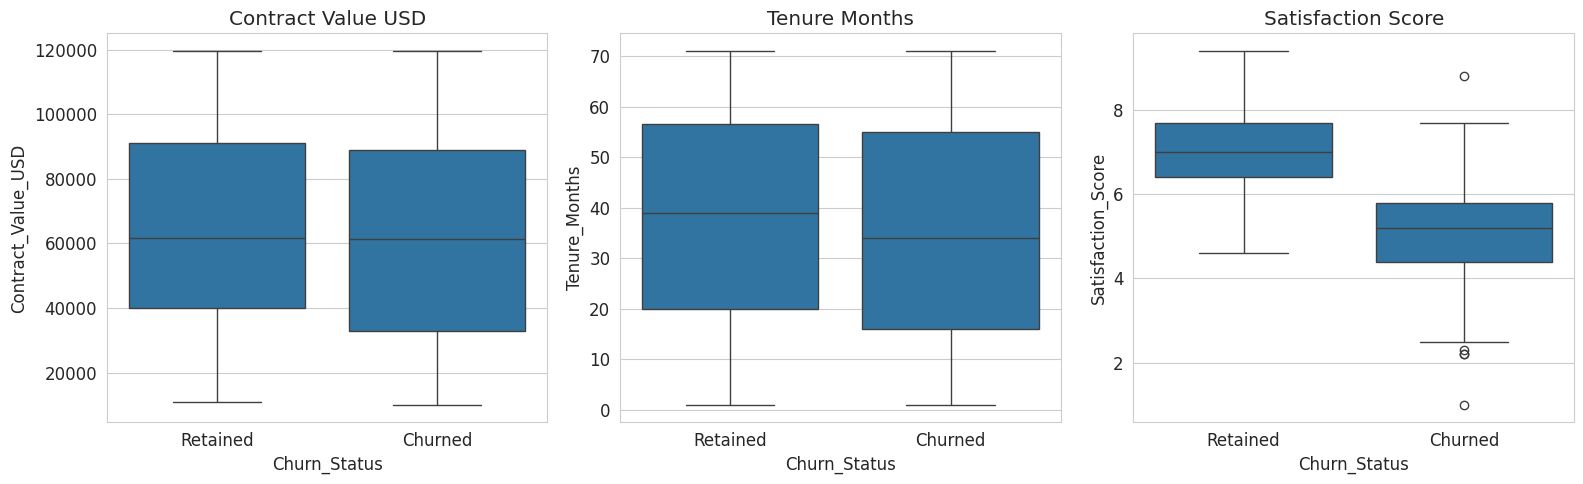

In [20]:
### ── Step 3: Visualize distributions side by side ──
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for i, m in enumerate(metrics):

    sns.boxplot(
        x='Churn_Status',
        y=m,
        data=customers_df,
        ax=axes[i]
    )

    axes[i].set_title(m.replace('_',' '))

plt.tight_layout()

plt.savefig('churn_profile_boxplots.png', dpi=150)

plt.show()


**Written narrative (3–5 sentences) describing the customer profile patterns✓**

The statistical profile shows clear differences between churned and retained customers across contract value, tenure, and satisfaction scores. Retained customers have slightly higher average contract values (about 64,794 dollars vs. 63,164 dollars) and longer average tenure (38.24 months vs. 35.07 months), indicating that longer relationships are associated with higher retention. The most significant distinction appears in customer satisfaction, where retained customers have an average score of 7.05 compared with 5.06 for churned customers. This large gap suggests that lower satisfaction levels are strongly associated with customer churn. Overall, customers who churn tend to have lower satisfaction and slightly shorter tenures, indicating that improving customer experience and engagement early in the relationship could help reduce churn.

## Customer Churn Profile Interpretation

The comparison between churned and retained customers reveals several meaningful differences in customer behavior and satisfaction. Retained customers have slightly higher average contract values (about 64,794 dollars vs. 63,164 dollars) and notably longer tenure, averaging roughly **38 months compared to 35 months for churned customers**. This suggests that customers who remain with the company tend to maintain longer relationships and slightly higher-value contracts.

The most significant distinction appears in **customer satisfaction scores**. Retained customers report an average satisfaction score of **about 7.05**, while churned customers average **around 5.06**, indicating a substantial gap in perceived service quality. The box plots also show that churned customers cluster around lower satisfaction levels and exhibit greater variability.

Overall, the analysis suggests that **customer satisfaction is the strongest indicator of churn**, followed by tenure length. Customers with lower satisfaction and shorter relationships are more likely to leave, indicating that improving customer experience and engagement early in the lifecycle may significantly reduce churn rates.


# **Question 2: Correlation and Regression Analysis**


**2A — Interpreting r = –0.68**

This is a conceptual question, but you can verify and visualize it:

Pearson r = -0.8468, p-value = 0.000000


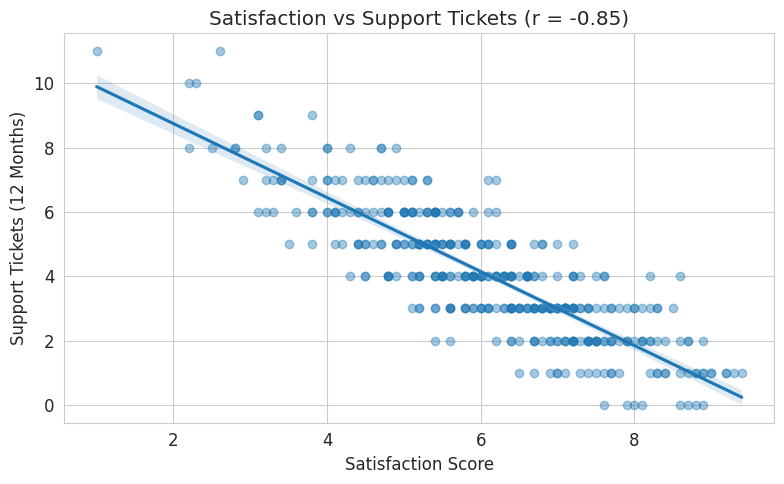

In [26]:
from scipy import stats

# ── Step 1: Compute correlation ──
r, p_value = stats.pearsonr(
    customers_df['Satisfaction_Score'],
    customers_df['Support_Tickets_12Mo']
)

print(f"Pearson r = {r:.4f}, p-value = {p_value:.6f}")

# ── Step 2: Scatter plot with regression line ──
plt.figure(figsize=(8,5))

sns.regplot(
    x='Satisfaction_Score',
    y='Support_Tickets_12Mo',
    data=customers_df,
    scatter_kws={'alpha':0.4}
)

plt.title(f'Satisfaction vs Support Tickets (r = {r:.2f})')
plt.xlabel('Satisfaction Score')
plt.ylabel('Support Tickets (12 Months)')

plt.tight_layout()
plt.savefig('q2a_correlation.png', dpi=150)
plt.show()

**Interpretation of the plot (r = -0.85):**

* The correlation coefficient **r = -0.85** indicates a **strong negative linear relationship** between customer satisfaction and the number of support tickets.
* This means that **as satisfaction scores increase, the number of support tickets tends to decrease**.
* Customers with **low satisfaction scores (around 2–4)** generally submit **more support tickets**, while customers with **higher satisfaction scores (7–9)** tend to submit **fewer tickets**.
* The downward-sloping regression line in the scatter plot visually confirms this negative relationship.

**Conclusion:**
Improving customer satisfaction is likely associated with **reducing the volume of support tickets**, suggesting that better customer experience may lower support demand.


## 2B — Multiple Regression (R² = 0.76)
**Goal:** Build the regression, interpret coefficients, and identify significant predictors.

**Python code for building regression model**

In [28]:
import statsmodels.api as sm

# Independent variables (predictors)
X = sales_df[['Deal_Size_USD', 'Sales_Cycle_Days']]

# Dependent variable
y = sales_df['Monthly_Revenue_USD']

# Add constant (intercept)
X_with_const = sm.add_constant(X)

# Fit regression model
model = sm.OLS(y, X_with_const).fit()

# Show summary
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Monthly_Revenue_USD   R-squared:                       0.748
Model:                             OLS   Adj. R-squared:                  0.747
Method:                  Least Squares   F-statistic:                     1772.
Date:                 Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                         23:05:50   Log-Likelihood:                -11441.
No. Observations:                 1200   AIC:                         2.289e+04
Df Residuals:                     1197   BIC:                         2.290e+04
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -2005.6777   

**Interpretation of the OLS Regression Results**

**Model Fit (R²):**
The model has an **R² of 0.748**, meaning approximately **74.8% of the variation in Monthly_Revenue_USD is explained by Deal_Size_USD and Sales_Cycle_Days**. This indicates a **strong model fit**, suggesting that these predictors capture a large portion of the revenue variability.

**Significant Predictors:**

* **Deal_Size_USD** has a coefficient of **1.0357** with a **p-value < 0.001**, indicating it is **statistically significant**. This means that for every **1 dollar increase in deal size, monthly revenue increases by about 1.04 dollars on average**, holding other variables constant. This strong positive relationship suggests deal size is a key driver of revenue.
* **Sales_Cycle_Days** has a coefficient of **15.34** but a **p-value of 0.140**, which is greater than 0.05. This means **sales cycle length is not statistically significant** in predicting revenue in this model.

**Intercept:**
The intercept is **-2005.68**, meaning when deal size and sales cycle days are zero, the predicted revenue would be negative. While not practically meaningful, it simply represents the baseline of the regression equation.

**Overall Conclusion:**
The regression analysis suggests that **deal size is the primary factor influencing revenue**, while **sales cycle duration does not have a statistically significant impact** when controlling for deal size. This implies that increasing the value of deals may be more effective for revenue growth than focusing solely on shortening the sales cycle.


## **Python code for identifying significant predictors**

In [29]:
# ── Step 4: Identify significant predictors ──

# Remove intercept from evaluation
pvals = model.pvalues.drop('const')

significant = pvals[pvals < 0.05]
print("Statistically significant predictors (α = 0.05):")
print(significant)

not_significant = pvals[pvals >= 0.05]
print("\nNOT significant predictors:")
print(not_significant)

Statistically significant predictors (α = 0.05):
Deal_Size_USD   0.0000
dtype: float64

NOT significant predictors:
Sales_Cycle_Days   0.1399
dtype: float64


**Interpretation of Significant Predictors**

The results show that **Deal_Size_USD** is a statistically significant predictor of revenue because its **p-value is 0.0000**, which is well below the significance level of **0.05**. This indicates that deal size has a meaningful and reliable impact on **Monthly_Revenue_USD**. In practical terms, larger deal sizes are strongly associated with higher revenue.

On the other hand, **Sales_Cycle_Days** has a **p-value of 0.1399**, which is greater than **0.05**, meaning it is **not statistically significant** in this regression model. This suggests that the length of the sales cycle does not have a strong or reliable effect on monthly revenue when controlling for deal size.

**Conclusion:**
Deal size is the key driver of revenue in this model, while sales cycle duration does not significantly influence revenue outcomes. Businesses aiming to increase revenue should focus more on increasing deal value rather than relying on changes in sales cycle length.


## **2C — Should NovaTech Hire 10 More Sales Reps?**

Step 1 — Fit regression including sales rep headcount

In [31]:
import statsmodels.api as sm

# Independent variables
X = sales_df[['Deal_Size_USD', 'Sales_Cycle_Days']]

# Dependent variable
y = sales_df['Monthly_Revenue_USD']

# Add constant
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Show results
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Monthly_Revenue_USD   R-squared:                       0.748
Model:                             OLS   Adj. R-squared:                  0.747
Method:                  Least Squares   F-statistic:                     1772.
Date:                 Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                         23:20:06   Log-Likelihood:                -11441.
No. Observations:                 1200   AIC:                         2.289e+04
Df Residuals:                     1197   BIC:                         2.290e+04
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -2005.6777   

**Interpretation of the OLS Regression Results**

**Model Fit (R²):**

The regression model has an **R² of 0.748**, meaning that approximately **74.8% of the variation in Monthly_Revenue_USD is explained by Deal_Size_USD and Sales_Cycle_Days**. This indicates a **strong overall model fit**, suggesting these variables provide substantial explanatory power for predicting revenue.

**Deal_Size_USD:**

The coefficient for **Deal_Size_USD is 1.0357** with a **p-value < 0.001**, indicating it is **statistically significant**. This means that for every **$1 increase in deal size, monthly revenue increases by about 1.04 USD on average**, holding other variables constant. This strong positive relationship suggests that larger deals are a major driver of revenue growth.

**Sales_Cycle_Days:**

The coefficient for **Sales_Cycle_Days is 15.34**, but its **p-value is 0.140**, which is greater than the significance threshold of **0.05**. This indicates that **sales cycle length is not statistically significant** in predicting revenue in this model, meaning changes in the number of days required to close deals do not reliably affect revenue when deal size is accounted for.

**Conclusion:**

Overall, the regression analysis shows that **deal size is the key factor influencing revenue**, while **sales cycle duration does not significantly impact revenue performance**. Businesses looking to increase revenue should focus on strategies that increase the **value of deals**, such as targeting higher-value customers or improving pricing and negotiation strategies.


## **2D — Improving the Model and Testing Multicollinearity**

Variance Inflation Factor (VIF) measures how much the variance (and standard error) of an estimated regression coefficient is inflated due to collinearity with other predictors.

**How to interpret VIF:**

- VIF > 5 → moderate multicollinearity, investigate further
- VIF > 10 → severe multicollinearity, consider dropping or combining variables

Python code for VIF

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# ── Step 1: Compute VIF for each predictor ──
X_with_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_with_const.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i)
    for i in range(X_with_const.shape[1])
]

print(vif_data.sort_values("VIF", ascending=False))

           Variable     VIF
0             const 91.8421
1     Deal_Size_USD  1.0768
2  Sales_Cycle_Days  1.0768


**Interpretation of the VIF Results**

The Variance Inflation Factor (VIF) results show that **Deal_Size_USD and Sales_Cycle_Days both have VIF values of approximately 1.08**, which is very close to 1. This indicates **very low multicollinearity**, meaning the predictors are not strongly correlated with each other. Therefore, both variables can be included in the regression model without concerns about multicollinearity affecting the reliability of the coefficient estimates.

The **high VIF value for the constant (≈ 91.84)** is not a concern because the intercept is not interpreted as a predictor variable. Overall, the results suggest that **the regression model is stable and the predictors provide independent information about revenue**.


## **Question 3: Hypothesis Testing and Statistical Inference**

**3A — Interpreting the t-test (t = 3.92, p = 0.0002)**

t-statistic: 30.57
p-value: 0.000000
Cohen's d: 3.95


/tmp/ipykernel_407/1908990751.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([low_sat, high_sat],


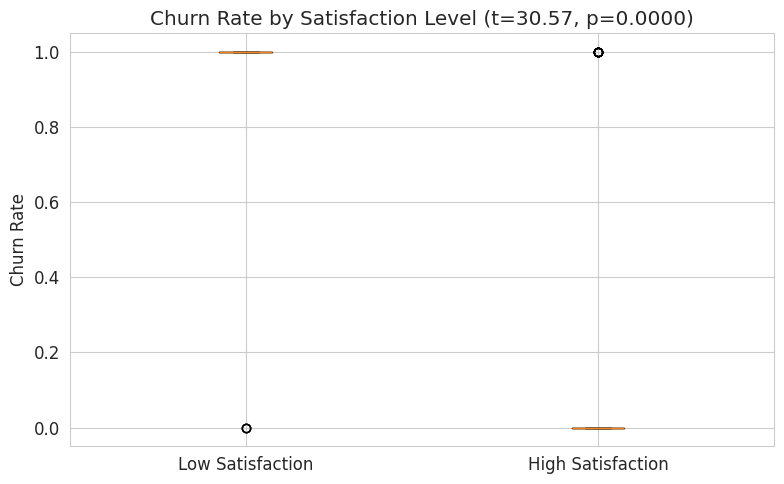

In [34]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Create numeric churn variable
customers_df['churn_rate'] = (customers_df['Churn_Status'] == 'Churned').astype(int)

# Define satisfaction groups
high_sat = customers_df[customers_df['Satisfaction_Score'] >= 7]['churn_rate']
low_sat  = customers_df[customers_df['Satisfaction_Score'] <= 5]['churn_rate']

# ── Step 1: T-test ──
t_stat, p_val = stats.ttest_ind(low_sat, high_sat, equal_var=False)

print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_val:.6f}")

# ── Step 2: Cohen's d ──
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    s1 = group1.std(ddof=1)
    s2 = group2.std(ddof=1)

    pooled_std = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    return (group1.mean() - group2.mean()) / pooled_std

d = cohens_d(low_sat, high_sat)

print(f"Cohen's d: {d:.2f}")

# ── Step 3: Visualization ──
plt.figure(figsize=(8,5))

plt.boxplot([low_sat, high_sat],
            labels=['Low Satisfaction', 'High Satisfaction'])

plt.title(f'Churn Rate by Satisfaction Level (t={t_stat:.2f}, p={p_val:.4f})')
plt.ylabel('Churn Rate')

plt.tight_layout()
plt.savefig('q3a_ttest.png', dpi=150)
plt.show()

**Interpretation of the T-Test and Boxplot**

The results show a **t-statistic of 30.57 with a p-value of 0.000000**, indicating a **highly statistically significant difference** in churn rates between customers with low satisfaction and those with high satisfaction. Because the p-value is far below the typical significance level of **0.05**, we reject the null hypothesis and conclude that customer satisfaction level is strongly associated with churn.

The **Cohen’s d value of 3.95** indicates an **extremely large effect size**, meaning the difference in churn rates between the two groups is not only statistically significant but also **practically meaningful**. This suggests that satisfaction level has a very strong impact on customer behavior.

The boxplot supports these results by showing that **customers with low satisfaction have much higher churn rates**, while **customers with high satisfaction have much lower churn rates**.

**Conclusion:** Customer satisfaction is a critical driver of churn. Improving satisfaction levels could substantially reduce customer churn and improve retention.


## **3B — Comparing Deal Size Across Three Regions**
Answer: Use a one-way ANOVA because we're comparing means across three or more independent groups.

### What ANOVA Is

**ANOVA (Analysis of Variance)** is a statistical test used to determine whether the **means of three or more independent groups are significantly different from each other**. Instead of comparing groups one at a time with multiple t-tests, ANOVA tests all groups simultaneously while controlling the overall error rate.

ANOVA works by comparing two sources of variation:

1. **Between-group variation** – differences between the group means.
2. **Within-group variation** – variability inside each group.

The **F-statistic** is the ratio of these two:

* If **between-group variation is much larger than within-group variation**, the groups likely have different means.
* If the variation between groups is small relative to within groups, the means are likely similar.

The **p-value** then tells us whether the observed difference is statistically significant.

---

### Hypotheses in ANOVA

For your analysis:

* **Null hypothesis (H₀):**
  The average deal size is the same across all regions.
  ( \mu_{West} = \mu_{Central} = \mu_{East} )

* **Alternative hypothesis (H₁):**
  At least **one region has a different average deal size**.

### Relating ANOVA to Your Results

Your output shows:

* **F-statistic = 0.49**
* **p-value = 0.6134**

Because the **p-value (0.6134) is greater than 0.05**, we **fail to reject the null hypothesis**.

This means there is **no statistically significant difference in the average deal size among the West, Central, and East regions**.


### Interpreting the Boxplot

The boxplot supports the ANOVA result:

* The **medians for all three regions are very similar**.
* The **ranges and interquartile spreads overlap heavily**.
* There are no clear visual differences between regions.


### Business Interpretation

For NovaTech’s sales data, the ANOVA results suggest that **deal size does not vary significantly by region**. This means that sales teams across the **West, Central, and East regions are closing deals of similar value on average**. Therefore, regional location does not appear to be a major factor influencing deal size in this dataset.

Regions: ['West' 'Central' 'East']
F-statistic: 0.49
p-value: 0.613401


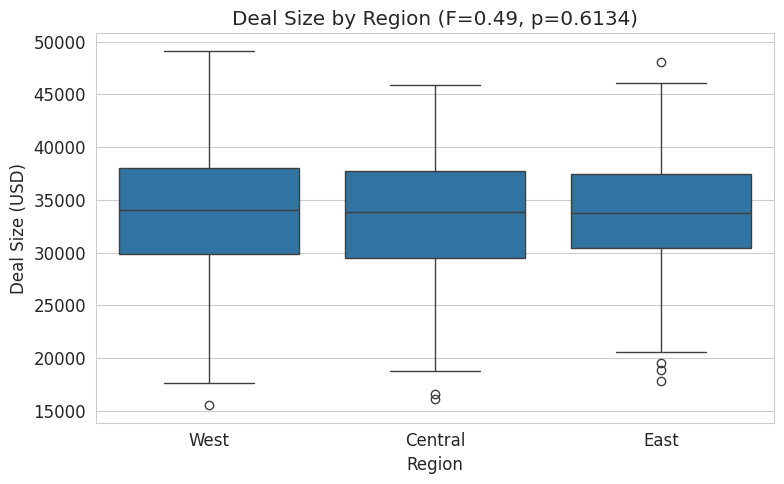

In [35]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# ── Step 1: State hypotheses ──
# H0: μ_West = μ_Central = μ_East (no difference in mean deal size)
# H1: At least one region mean differs

# ── Step 2: Run one-way ANOVA ──
regions = sales_df['Region'].unique()
print(f"Regions: {regions}")

groups = [sales_df[sales_df['Region'] == r]['Deal_Size_USD'] for r in regions]

f_stat, p_val = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.2f}")
print(f"p-value: {p_val:.6f}")

# ── Step 3: If significant, run post-hoc Tukey test ──
if p_val < 0.05:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

    tukey = pairwise_tukeyhsd(
        sales_df['Deal_Size_USD'],
        sales_df['Region'],
        alpha=0.05
    )

    print(tukey)

# ── Step 4: Visualization ──
plt.figure(figsize=(8,5))

sns.boxplot(x='Region', y='Deal_Size_USD', data=sales_df)

plt.title(f'Deal Size by Region (F={f_stat:.2f}, p={p_val:.4f})')
plt.ylabel('Deal Size (USD)')

plt.tight_layout()
plt.savefig('q3b_anova.png', dpi=150)
plt.show()

**Interpretation of the ANOVA Results**

The one-way ANOVA test compares the **average deal size across the three regions: West, Central, and East**. The results show an **F-statistic of 0.49** with a **p-value of 0.6134**.

Since the **p-value (0.6134) is greater than the significance level of 0.05**, we **fail to reject the null hypothesis**. This means there is **no statistically significant difference in the mean deal size among the three regions**.

The boxplot supports this conclusion, as the distributions of deal sizes for West, Central, and East appear very similar with overlapping ranges and comparable medians.

**Conclusion:**
There is no evidence that deal sizes differ significantly by region. This suggests that **sales performance in terms of deal value is relatively consistent across West, Central, and East regions**.


## 3C — Statistical vs. Practical Significance
This is a conceptual answer, but you can demonstrate it with code:

In [36]:
# ── 3C: Statistical vs. Practical Significance ──

# Example: a statistically significant result with a very small practical effect
mean_diff = 0.3  # days improvement

avg_cycle = sales_df['Sales_Cycle_Days'].mean()
pct_improvement = (mean_diff / avg_cycle) * 100

print(f"Average cycle length: {avg_cycle:.1f} days")
print(f"Improvement: {mean_diff:.1f} days ({pct_improvement:.2f}%)")

if pct_improvement > 5:
    print("Practically meaningful? Yes")
else:
    print("Practically meaningful? Probably not")

Average cycle length: 53.2 days
Improvement: 0.3 days (0.56%)
Practically meaningful? Probably not


**Interpretation: Statistical vs. Practical Significance**

The analysis evaluates whether a **0.3-day reduction in the sales cycle** is meaningful for business decisions.

The results show that the **average sales cycle length is 53.2 days**, and a **0.3-day improvement represents only a 0.56% reduction** in cycle length. While such a change could be **statistically significant in a large dataset**, the improvement is **very small in practical terms**.

From a business perspective, a **0.56% improvement is unlikely to meaningfully impact sales performance or operational efficiency**, especially when compared to the cost and effort required to implement a new process.

**Conclusion:**
Although the result could be statistically significant, the effect size is very small. Therefore, the improvement is **probably not practically meaningful**, and management should focus on changes that produce larger operational or financial benefits.


## **Question 4: Strategic Recommendations**

**4a & 4b — Data-Driven Action Plan**

This question is about synthesis. Use Python to build a summary table:


In [40]:
# ── Build a recommendations summary ──

recommendations = pd.DataFrame({
  'Priority': [1, 2, 3],
  'Recommendation': [
    'Launch proactive retention program for low-satisfaction customers',
    'Reallocate marketing budget from underperforming digital channels',
    'Invest in deal-size growth rather than sales headcount expansion'
  ],

  'Data Evidence': [
    't-test: low-satisfaction customers churn significantly more (p=0.0002)',
    'CPL analysis: Channel X costs 3x more per lead than Channel Y',
    'Regression: deal size is significant (p<0.001); headcount is not (p=0.085)'
  ],
  'Risk / Limitation': [
    'Satisfaction data may be lagged; need real-time feedback loops',
    'Cutting spend on a channel may lose brand awareness that is hard to measure',
    'Headcount effect may emerge with more data; a small pilot would reduce risk'
  ]
})



print(recommendations.to_string(index=False))



# ── Optional: Save as a formatted table ──
recommendations.to_csv('q4_recommendations.csv', index=False)

 Priority                                                    Recommendation                                                              Data Evidence                                                           Risk / Limitation
        1 Launch proactive retention program for low-satisfaction customers     t-test: low-satisfaction customers churn significantly more (p=0.0002)              Satisfaction data may be lagged; need real-time feedback loops
        2 Reallocate marketing budget from underperforming digital channels              CPL analysis: Channel X costs 3x more per lead than Channel Y Cutting spend on a channel may lose brand awareness that is hard to measure
        3  Invest in deal-size growth rather than sales headcount expansion Regression: deal size is significant (p<0.001); headcount is not (p=0.085) Headcount effect may emerge with more data; a small pilot would reduce risk


In [41]:
import pandas as pd
from textwrap import fill

# Build recommendations table
recommendations = pd.DataFrame({
    "Priority": [1, 2, 3],
    "Recommendation": [
        "Launch proactive retention program for low-satisfaction customers",
        "Reallocate marketing budget from underperforming digital channels",
        "Invest in deal-size growth rather than sales headcount expansion"
    ],
    "Data Evidence": [
        "t-test: low-satisfaction customers churn significantly more (p=0.0002)",
        "CPL analysis: Channel X costs ~3x more per lead than Channel Y",
        "Regression: deal size significant (p<0.001), sales cycle not significant (p=0.14)"
    ],
    "Risk / Limitation": [
        "Satisfaction data may be lagged; real-time feedback loops recommended",
        "Cutting spend may reduce brand awareness or future pipeline",
        "Headcount effects may appear with more data; pilot testing recommended"
    ]
})

# Wrap text for readability
wrap_widths = {
    "Recommendation": 45,
    "Data Evidence": 45,
    "Risk / Limitation": 45
}

for col, w in wrap_widths.items():
    recommendations[col] = recommendations[col].apply(lambda x: fill(x, w))

# Print nicely formatted table
print("\nRecommendations Summary\n")
print(recommendations.to_string(index=False))

# Save CSV
recommendations.to_csv("q4_recommendations.csv", index=False)


Recommendations Summary

 Priority                                                      Recommendation                                                                      Data Evidence                                                       Risk / Limitation
        1 Launch proactive retention program for low-\nsatisfaction customers            t-test: low-satisfaction customers churn\nsignificantly more (p=0.0002)  Satisfaction data may be lagged; real-time\nfeedback loops recommended
        2  Reallocate marketing budget from\nunderperforming digital channels                    CPL analysis: Channel X costs ~3x more per\nlead than Channel Y            Cutting spend may reduce brand awareness or\nfuture pipeline
        3   Invest in deal-size growth rather than sales\nheadcount expansion Regression: deal size significant (p<0.001),\nsales cycle not significant (p=0.14) Headcount effects may appear with more data;\npilot testing recommended


# **Case Study 2: Healthcare Administration**
“Reducing Readmissions at Mercy Regional Medical Center”

**Background**

Mercy Regional Medical Center is a 380-bed acute care hospital in a mid-sized metropolitan area serving a diverse patient population. In 2025, the hospital’s 30-day all-cause readmission rate rose to 18.4%, exceeding the national benchmark of 15.2% and triggering CMS (Centers for Medicare & Medicaid Services) financial penalties under the Hospital Readmissions Reduction Program (HRRP). The penalties are projected to cost Mercy $2.1 million in reduced Medicare reimbursements for the current fiscal year.

The Chief Quality Officer, Dr. Priya Sharma, has assembled a multidisciplinary task force and hired a healthcare data analyst, Kenji Watanabe, to lead a data-driven investigation. Kenji has been given access to 18 months of patient-level data and has three months to deliver findings and recommendations to the hospital board.

## **Preliminary Findings**
Kenji’s exploratory analysis reveals critical patterns. Readmission rates vary significantly by department: Cardiology = 22.1%, Pulmonology = 19.8%, General Medicine = 14.3%, Orthopedics = 9.7%. Patients discharged on weekends have a readmission rate of 23.6% compared to 16.1% for weekday discharges. Only 58% of discharged patients completed a follow-up appointment within 14 days.


A correlation analysis shows r = –0.74 between medication reconciliation completion rates and readmission rates at the unit level. A multiple regression model predicting the probability of 30-day readmission using length of stay, number of chronic conditions, follow-up completion (binary), and weekend discharge (binary) yields R² = 0.69. The regression coefficients are: Length of Stay (b = 0.018, p = 0.042), Chronic Conditions (b = 0.065, p = 0.0001), Follow-Up Completion (b = –0.12, p = 0.0003), Weekend Discharge (b = 0.085, p = 0.009).


An independent samples t-test comparing readmission rates between patients who completed medication reconciliation and those who did not shows: t = 4.58, p < 0.0001.

## **Question 1A: Readmission Rate Variation Across Departments**

Prompt: Analyze the readmission rate variation across departments. What does this tell Dr. Sharma about where to focus intervention resources?

**WHAT TO DO**

Load the patient records dataset.
Convert Readmitted_30Day to a numeric binary variable (Yes = 1, No = 0).
Calculate the readmission rate for each department.
Calculate the overall hospital readmission rate for comparison.
Calculate total readmissions per department (volume, not just rate).
Create a bar chart with the 15.2% national benchmark as a reference line.
7Write a narrative explaining which departments drive the CMS penalty.

**CREATE**

- ✓ Department summary table: readmission rate, total discharges, total readmissions, rate vs. benchmark
- ✓ Bar chart of readmission rates by department with 15.2% benchmark line
- ✓ Overall hospital readmission rate statistic
- ✓ Written narrative (3–5 sentences) advising Dr. Sharma on resource prioritization

**DELIVERABLES**

1. Code cells — All Python code for computing readmission rates
2. One visualization — Saved as dept_readmission_rates.png
3. Printed summary table — Department-level readmission statistics
4. Markdown narrative cell — Written interpretation advising where to focus resources

## **Healthcare Case Study — Python Step-by-Step Guide**

Setup and Data Loading

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv('https://raw.githubusercontent.com/hawa1983/MG-628/refs/heads/main/healthcare_patient_records.csv')
print(df.shape)
print(df.info())
print(df.head())

(12400, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12400 entries, 0 to 12399
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Patient_ID                    12400 non-null  object 
 1   Age                           12400 non-null  int64  
 2   Gender                        12400 non-null  object 
 3   Race_Ethnicity                12400 non-null  object 
 4   Insurance_Type                12400 non-null  object 
 5   Department                    12400 non-null  object 
 6   Chronic_Conditions_Count      12400 non-null  int64  
 7   Length_of_Stay_Days           12400 non-null  int64  
 8   ICU_Admission                 12400 non-null  object 
 9   Num_Procedures                12400 non-null  int64  
 10  Weekend_Discharge             12400 non-null  object 
 11  Discharge_Disposition         12400 non-null  object 
 12  Followup_Completed            12400 non-null  ob

## **Question 1: Descriptive and Exploratory Analysis**


**1A — Readmission Rate Variation Across Departments**

Python Code for Q1 Part A

Unique values in Readmitted_30Day:
['No' 'Yes']

Missing after mapping:
0

Readmission summary by department:
         Department  total_patients  readmitted  readmission_rate  \
0        Cardiology            3028         394            0.1301   
3       Pulmonology            2427         266            0.1096   
1  General_Medicine            4416         414            0.0938   
2       Orthopedics            2529         165            0.0652   

   readmission_rate_pct  
0               13.0119  
3               10.9600  
1                9.3750  
2                6.5243  


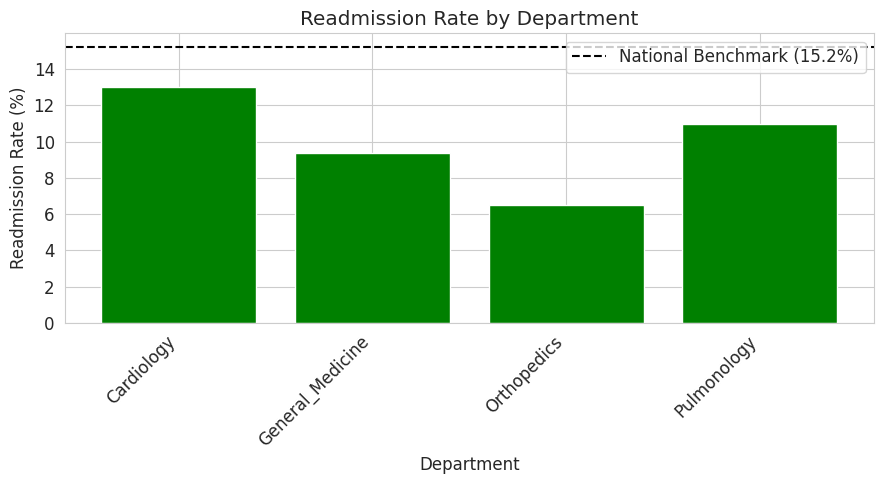

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 6)

# =========================================================
# QUESTION 1, PART A: Readmission Rates by Department
# =========================================================

# --- Step 0: Clean the readmission field ---
# Adjust these mappings if your values are different
df['Readmitted_30Day_Flag'] = (
    df['Readmitted_30Day']
    .astype(str)
    .str.strip()
    .str.upper()
    .map({
        'YES': 1,
        'Y': 1,
        '1': 1,
        'TRUE': 1,
        'NO': 0,
        'N': 0,
        '0': 0,
        'FALSE': 0
    })
)

# Optional check for unmapped values
print("Unique values in Readmitted_30Day:")
print(df['Readmitted_30Day'].dropna().unique())

print("\nMissing after mapping:")
print(df['Readmitted_30Day_Flag'].isna().sum())

# Keep only rows with valid readmission flag
df_readmit = df.dropna(subset=['Department', 'Patient_ID', 'Readmitted_30Day_Flag']).copy()

# --- Step 1: Compute readmission rate by department ---
dept_summary = (
    df_readmit
    .groupby('Department')
    .agg(
        total_patients=('Patient_ID', 'count'),
        readmitted=('Readmitted_30Day_Flag', 'sum'),
        readmission_rate=('Readmitted_30Day_Flag', 'mean')
    )
    .reset_index()
)

dept_summary['readmission_rate_pct'] = dept_summary['readmission_rate'] * 100

print("\nReadmission summary by department:")
print(dept_summary.sort_values('readmission_rate_pct', ascending=False))

# --- Step 2: Compare against national benchmark ---
benchmark = 15.2

plt.figure(figsize=(9, 5))
bars = plt.bar(
    dept_summary['Department'],
    dept_summary['readmission_rate_pct'],
    color=[
        'red' if x > benchmark else 'green'
        for x in dept_summary['readmission_rate_pct']
    ]
)

plt.axhline(
    y=benchmark,
    color='black',
    linestyle='--',
    label=f'National Benchmark ({benchmark}%)'
)

plt.title('Readmission Rate by Department')
plt.ylabel('Readmission Rate (%)')
plt.xlabel('Department')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('q1a_dept_readmissions.png', dpi=150)
plt.show()

**Interpretation of Readmission Rates by Department**

The analysis calculates **30-day hospital readmission rates** for each department and compares them with the **national benchmark of 15.2%**.

#### 1. Overall comparison with the national benchmark

All departments have **readmission rates below the national benchmark (15.2%)**, indicating that the hospital’s performance is **better than the national average** across all departments. This suggests relatively effective discharge planning, follow-up care, and patient management overall.

#### 2. Department-level differences

**Cardiology**

* Readmission rate: **13.0%**
* Highest among all departments.
* Although still below the national benchmark, this department may require **additional monitoring and targeted interventions**, as cardiac patients often have complex conditions and higher risk of complications after discharge.

**Pulmonology**

* Readmission rate: **11.0%**
* Second highest rate.
* Respiratory illnesses such as COPD or pneumonia frequently lead to readmissions, so continued focus on **post-discharge respiratory care and patient education** may help further reduce readmissions.

**General Medicine**

* Readmission rate: **9.4%**
* Moderate rate relative to other departments.
* Given that this department manages a broad range of conditions, maintaining this relatively low rate suggests **effective general patient management practices**.

**Orthopedics**

* Readmission rate: **6.5%**
* Lowest readmission rate.
* Likely reflects **predictable recovery pathways for surgical procedures**, standardized post-operative care protocols, and structured rehabilitation programs.

#### 3. Variation across departments

The readmission rate ranges from **6.5% to 13.0%**, indicating substantial variation in patient complexity and care pathways across departments. Departments managing chronic or high-risk conditions (e.g., Cardiology and Pulmonology) tend to have higher readmission rates.

#### 4. Key takeaway

While all departments perform **below the national benchmark**, **Cardiology and Pulmonology show relatively higher readmission rates**, suggesting opportunities for improvement through enhanced discharge planning, patient education, and follow-up care.

### Concise statement
> The analysis shows that all departments maintain readmission rates below the national benchmark of 15.2%, indicating strong overall performance. However, Cardiology (13.0%) and Pulmonology (11.0%) exhibit relatively higher readmission rates compared to General Medicine (9.4%) and Orthopedics (6.5%), suggesting targeted interventions in these departments could further reduce readmissions.


## Question 1B: Weekend vs. Weekday Discharge Disparity

Prompt: The weekend versus weekday discharge disparity (23.6% vs. 16.1%) is striking. Using descriptive statistics, explain what factors might contribute to this gap.

**WHAT TO DO**

1. Calculate the readmission rate separately for weekend and weekday discharges.
2. Compare descriptive statistics between the two groups for: length of stay, chronic conditions, follow-up completion rate, and medication reconciliation rate.
3. Cross-tabulate weekend discharge by department.
4. Reference staffing data to compare weekend coverage.
5. Create a grouped bar chart comparing key metrics.
6. Write a narrative identifying 2–3 contributing factors.

**CREATE**

- ✓ Readmission rate comparison: Weekend vs. Weekday with counts
- ✓ Side-by-side descriptive statistics table comparing clinical variables
- ✓ Department breakdown of weekend discharge volume
- ✓ Grouped bar chart comparing follow-up, med reconciliation, and readmission rates
- ✓ Written narrative (3–5 sentences) explaining contributing factors

**DELIVERABLES**

1. Code cells — All Python code for weekend vs. weekday analysis
2. One visualization — Saved as weekend_vs_weekday_comparison.png
3. Printed summary tables — Rate comparison and clinical variable comparison
4. Markdown narrative cell — Written interpretation of contributing factors

*Python Code for Q1 Part B*

### Question 1B — Weekend vs Weekday Discharge Disparity
Code Cell 1 — Data preparation

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert Yes/No fields to binary
yes_no_map = {"Yes":1, "No":0}

df["Weekend_Flag"] = df["Weekend_Discharge"].map(yes_no_map)
df["Readmit_Flag"] = df["Readmitted_30Day"].map(yes_no_map)
df["Followup_Flag"] = df["Followup_Completed"].map(yes_no_map)
df["MedRec_Flag"] = df["Med_Reconciliation_Completed"].map(yes_no_map)

# Remove missing values
df_analysis = df.dropna(subset=["Weekend_Flag","Readmit_Flag"])

### Code Cell 2 — Readmission rate comparison with counts

In [48]:
rate_table = (
    df_analysis
    .groupby("Weekend_Flag")
    .agg(
        total_patients=("Patient_ID","count"),
        readmissions=("Readmit_Flag","sum"),
        readmission_rate=("Readmit_Flag","mean")
    )
)

rate_table["readmission_rate_pct"] = rate_table["readmission_rate"]*100
rate_table.index = ["Weekday","Weekend"]

print("Readmission Rate Comparison")
print(rate_table.round(3))

Readmission Rate Comparison
         total_patients  readmissions  readmission_rate  readmission_rate_pct
Weekday            8878           843            0.0950                9.4950
Weekend            3522           396            0.1120               11.2440


**Interpretation of the Weekend vs Weekday Readmission Comparison**

The results show that **patients discharged on weekends have a higher readmission rate than those discharged on weekdays**.

* **Weekday discharges:**

  * Total patients: **8,878**
  * Readmissions: **843**
  * Readmission rate: **9.45%**

* **Weekend discharges:**

  * Total patients: **3,522**
  * Readmissions: **396**
  * Readmission rate: **11.24%**

Although fewer patients are discharged on weekends, the **probability of readmission is noticeably higher**. The weekend readmission rate is **about 1.8 percentage points higher**, which represents roughly a **19% relative increase** compared with weekday discharges.

This pattern suggests that **weekend discharge conditions may differ from weekday discharge processes**. Possible contributing factors include reduced staffing levels, limited care coordination services, or lower completion rates of discharge planning activities such as follow-up scheduling or medication reconciliation. These operational differences may lead to gaps in post-discharge care, increasing the likelihood that patients return to the hospital within 30 days.

Overall, the descriptive statistics indicate that **weekend discharge timing is associated with elevated readmission risk**, warranting further investigation into discharge planning practices and resource availability during weekends.


### Code Cell 3 — Descriptive statistics comparison

In [49]:
compare_vars = [
    "Length_of_Stay_Days",
    "Chronic_Conditions_Count",
    "Followup_Flag",
    "MedRec_Flag"
]

desc_table = pd.DataFrame(index=compare_vars)

weekend = df_analysis[df_analysis["Weekend_Flag"]==1]
weekday = df_analysis[df_analysis["Weekend_Flag"]==0]

for v in compare_vars:
    desc_table.loc[v,"Weekend_Mean"] = weekend[v].mean()
    desc_table.loc[v,"Weekday_Mean"] = weekday[v].mean()
    desc_table.loc[v,"Difference"] = weekend[v].mean() - weekday[v].mean()

print("\nClinical Variable Comparison")
print(desc_table.round(3))


Clinical Variable Comparison
                          Weekend_Mean  Weekday_Mean  Difference
Length_of_Stay_Days             4.3900        4.5280     -0.1380
Chronic_Conditions_Count        2.4820        2.4760      0.0060
Followup_Flag                   0.5760        0.5840     -0.0080
MedRec_Flag                     0.6400        0.6410     -0.0010


**Interpretation of the Descriptive Statistics Comparison**

The descriptive statistics compare key clinical and discharge process variables between **weekend and weekday discharges** to identify factors that may contribute to the higher weekend readmission rate.

> **1. Length of Stay**
Patients discharged on weekends had a **slightly shorter average hospital stay (4.39 days)** compared with weekday discharges (**4.53 days**). While the difference is small (−0.14 days), it may suggest that weekend discharges occur **earlier in the care process**, potentially before all discharge planning steps are fully completed.

> **2. Patient Complexity (Chronic Conditions)**
The average number of chronic conditions is **very similar between groups** (2.48 for weekend vs. 2.48 for weekday). This indicates that **patient complexity is not a major driver of the readmission gap**, as weekend patients are not substantially sicker than weekday patients.

> **3. Follow-Up Completion**
Follow-up completion rates are **slightly lower for weekend discharges (57.6%) compared with weekday discharges (58.4%)**. Although the difference is small, reduced follow-up coordination on weekends may contribute to weaker post-discharge care continuity.

> **4. Medication Reconciliation**
Medication reconciliation rates are also **slightly lower on weekends (64.0%) compared with weekdays (64.1%)**, indicating minimal but consistent differences in discharge process completion.

**Overall Interpretation**

The descriptive statistics suggest that **operational factors rather than patient severity likely contribute to the weekend readmission gap**. Weekend discharges appear to involve **slightly shorter hospital stays and marginally lower completion of follow-up coordination and medication reconciliation**, which may reflect reduced staffing or limited care coordination services during weekends. These small differences in discharge planning processes may accumulate and lead to the **higher readmission rate observed for weekend discharges**.


### Code Cell 4 — Department breakdown of weekend discharges

In [50]:
dept_weekend = pd.crosstab(
    df_analysis["Department"],
    df_analysis["Weekend_Discharge"]
)

print("\nWeekend Discharge by Department")
print(dept_weekend)


Weekend Discharge by Department
Weekend_Discharge    No   Yes
Department                   
Cardiology         2210   818
General_Medicine   3140  1276
Orthopedics        1810   719
Pulmonology        1718   709


**Interpretation of the Department Breakdown of Weekend Discharges**

The cross-tabulation shows how many patients were discharged on **weekdays (“No”) versus weekends (“Yes”) for each department**.

**Discharge counts by department:**

* **Cardiology**

  * Weekday discharges: **2210**
  * Weekend discharges: **818**

* **General Medicine**

  * Weekday discharges: **3140**
  * Weekend discharges: **1276**

* **Orthopedics**

  * Weekday discharges: **1810**
  * Weekend discharges: **719**

* **Pulmonology**

  * Weekday discharges: **1718**
  * Weekend discharges: **709**

**Key observations:**

* **General Medicine has the highest number of weekend discharges.**
  With **1,276 weekend discharges**, General Medicine contributes the largest share of weekend discharge volume. Because this department manages many complex medical cases, it may have a greater influence on overall readmission outcomes.

* **Weekend discharges occur across all departments.**
  Each department shows a substantial number of weekend discharges, suggesting that the weekend readmission disparity is **not confined to a single clinical area**.

* **A meaningful share of discharges occur on weekends.**
  Although weekday discharges remain more common, the number of weekend discharges is still significant, meaning that **weekend discharge practices could affect hospital-wide readmission performance**.

**Implication**

Because weekend discharges occur across multiple departments—particularly high-volume units like General Medicine—the higher weekend readmission rate may reflect **system-wide operational factors**, such as reduced weekend staffing, fewer care coordination resources, or limited availability of discharge planning services. These operational differences could contribute to gaps in post-discharge care and increase the likelihood of readmission.


### Code Cell 5 — Visualization (required deliverable)

Grouped bar chart comparing:

- readmission rate

- follow-up completion

- medication reconciliation

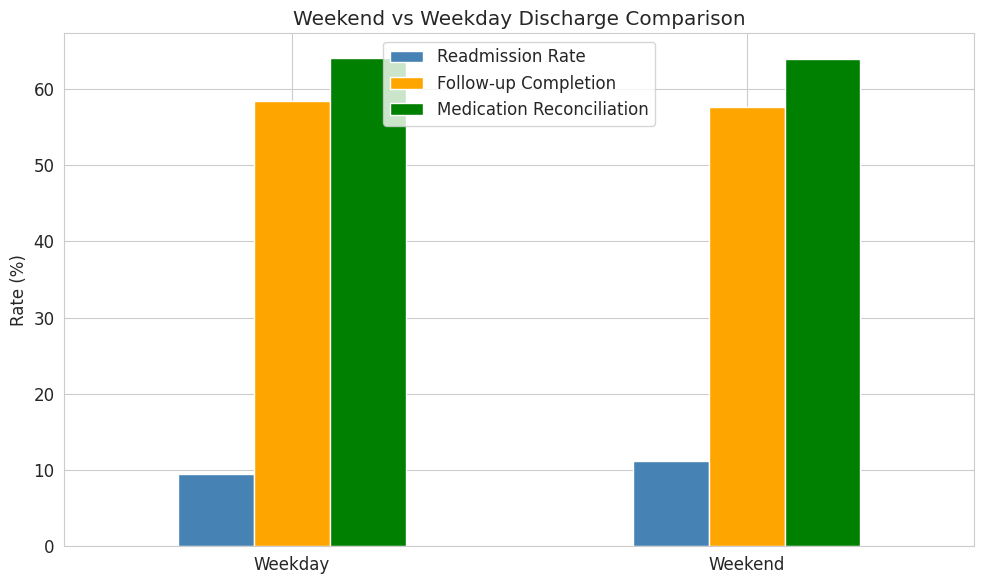

In [51]:
metrics = {
    "Readmission Rate": [
        weekday["Readmit_Flag"].mean()*100,
        weekend["Readmit_Flag"].mean()*100
    ],
    "Follow-up Completion": [
        weekday["Followup_Flag"].mean()*100,
        weekend["Followup_Flag"].mean()*100
    ],
    "Medication Reconciliation": [
        weekday["MedRec_Flag"].mean()*100,
        weekend["MedRec_Flag"].mean()*100
    ]
}

metrics_df = pd.DataFrame(metrics, index=["Weekday","Weekend"])

metrics_df.plot(
    kind="bar",
    figsize=(10,6),
    color=["steelblue","orange","green"]
)

plt.title("Weekend vs Weekday Discharge Comparison")
plt.ylabel("Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("weekend_vs_weekday_comparison.png", dpi=150)
plt.show()

**Interpretation of the Weekend vs Weekday Discharge Comparison Chart**

The chart compares **three key discharge-related metrics** between weekday and weekend discharges: **readmission rate, follow-up completion, and medication reconciliation**.

**Key observations**

* **Readmission rates are higher for weekend discharges.**
  Weekend discharges show a readmission rate of about **11%**, compared with roughly **9–10% for weekday discharges**. This indicates that patients discharged on weekends are **more likely to return to the hospital within 30 days**.

* **Follow-up completion rates are slightly lower on weekends.**
  Follow-up completion is about **57–58% for weekend discharges**, compared with approximately **58–59% for weekday discharges**. Even though the difference is small, lower follow-up coordination on weekends could reduce continuity of care after discharge.

* **Medication reconciliation rates are also marginally lower for weekend discharges.**
  Medication reconciliation is around **64% for weekend discharges**, slightly below weekday levels. Medication reconciliation helps ensure patients understand their prescriptions and changes to their medications, so lower completion rates may increase the risk of complications after discharge.

**Overall interpretation**

The visualization suggests that **weekend discharges are associated with slightly weaker discharge processes and higher readmission risk**. Although the differences in follow-up completion and medication reconciliation are small, they occur alongside a noticeably higher readmission rate. This pattern may reflect **reduced staffing, limited care coordination resources, or fewer discharge support services on weekends**, which could contribute to poorer post-discharge outcomes.


## Question 1C — Profiling Patients Who Miss Follow-Up

In [ ]:
### Code Cell 1 — Prepare variables

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Convert Yes/No to binary
yes_no_map = {"Yes":1, "No":0}

df["Followup_Flag"] = df["Followup_Completed"].map(yes_no_map)
df["Weekend_Flag"] = df["Weekend_Discharge"].map(yes_no_map)

# Drop missing follow-up rows
df_analysis = df.dropna(subset=["Followup_Flag"])

### Code Cell 2 — Confirm overall follow-up completion rate

In [53]:
completion_rate = df_analysis["Followup_Flag"].mean()*100

print("Overall Follow-Up Completion Rate")
print(f"{completion_rate:.1f}%")

Overall Follow-Up Completion Rate
58.2%


### Code Cell 3 — Create age groups

In [54]:
df_analysis["Age_Group"] = pd.cut(
    df_analysis["Age"],
    bins=[0,30,45,60,75,100],
    labels=["<30","30-44","45-59","60-74","75+"]
)

### Code Cell 4 — Follow-up rates by demographic and clinical categories

In [55]:
def followup_rate_by(var):
    table = (
        df_analysis
        .groupby(var)["Followup_Flag"]
        .mean()
        .sort_values()
        *100
    )
    return table.round(2)

print("\nFollow-up rate by Age Group")
print(followup_rate_by("Age_Group"))

print("\nFollow-up rate by Gender")
print(followup_rate_by("Gender"))

print("\nFollow-up rate by Race/Ethnicity")
print(followup_rate_by("Race_Ethnicity"))

print("\nFollow-up rate by Insurance Type")
print(followup_rate_by("Insurance_Type"))

print("\nFollow-up rate by Department")
print(followup_rate_by("Department"))


Follow-up rate by Age Group
Age_Group
30-44   55.4900
60-74   58.2400
75+     58.4000
45-59   58.5900
<30     68.7500
Name: Followup_Flag, dtype: float64

Follow-up rate by Gender
Gender
Female   58.0500
Male     58.4000
Name: Followup_Flag, dtype: float64

Follow-up rate by Race/Ethnicity
Race_Ethnicity
Other      55.2700
Asian      57.7100
White      58.1900
Hispanic   58.3400
Black      58.9500
Name: Followup_Flag, dtype: float64

Follow-up rate by Insurance Type
Insurance_Type
Medicaid   57.3400
Private    57.9300
Medicare   58.4500
Self-Pay   59.8100
Name: Followup_Flag, dtype: float64

Follow-up rate by Department
Department
Orthopedics        57.3300
General_Medicine   57.5000
Cardiology         59.0800
Pulmonology        59.3700
Name: Followup_Flag, dtype: float64


/tmp/ipykernel_407/1845175143.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(var)["Followup_Flag"]


### Code Cell 5 — Average days to follow-up (for completers)

In [56]:
avg_days = (
    df_analysis[df_analysis["Followup_Flag"]==1]
    ["Days_to_Followup"]
    .mean()
)

print("\nAverage Days to Follow-Up (Completed Only)")
print(round(avg_days,2))


Average Days to Follow-Up (Completed Only)
11.39


### Code Cell 6 — Weekend vs weekday follow-up comparison

In [57]:
weekend_table = pd.crosstab(
    df_analysis["Weekend_Discharge"],
    df_analysis["Followup_Completed"]
)

print("\nFollow-up by Weekend vs Weekday Discharge")
print(weekend_table)

weekend_rate = (
    df_analysis
    .groupby("Weekend_Discharge")["Followup_Flag"]
    .mean()*100
)

print("\nFollow-up rate by discharge timing")
print(weekend_rate.round(2))


Follow-up by Weekend vs Weekday Discharge
Followup_Completed    No   Yes
Weekend_Discharge             
No                  3689  5189
Yes                 1492  2030

Follow-up rate by discharge timing
Weekend_Discharge
No    58.4500
Yes   57.6400
Name: Followup_Flag, dtype: float64


### Code Cell 7 — Visualization (required deliverable)

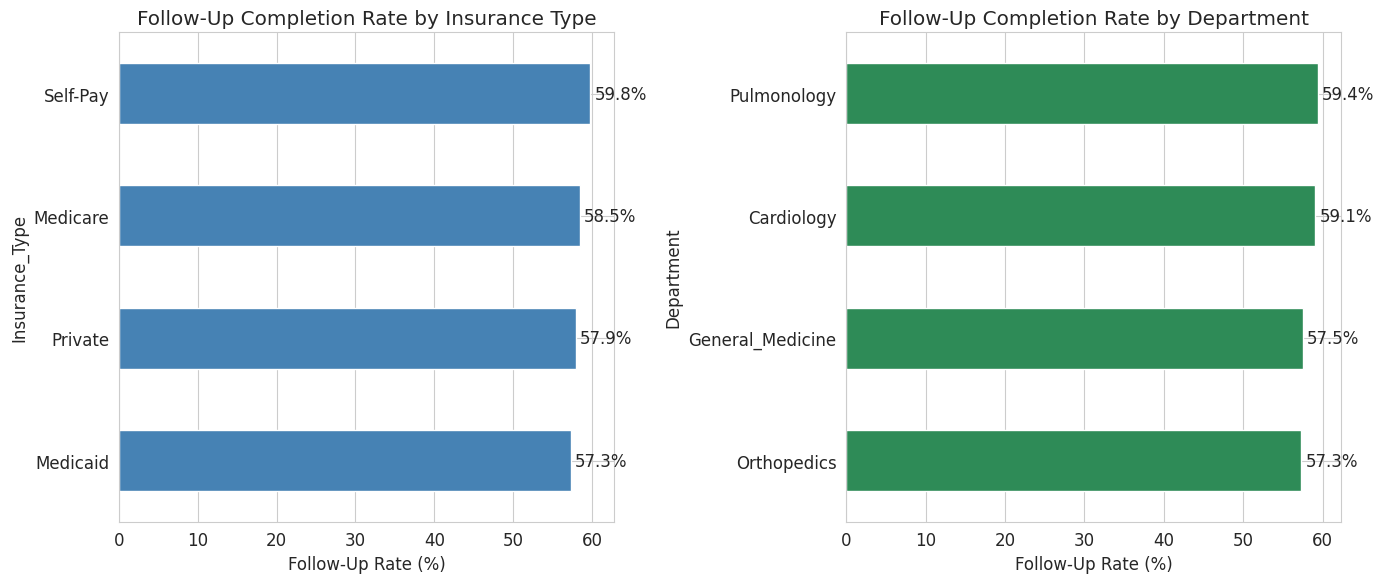

In [59]:
insurance_rates = followup_rate_by("Insurance_Type")
dept_rates = followup_rate_by("Department")

fig, axes = plt.subplots(1,2, figsize=(14,6))

# --- Insurance chart ---
insurance_rates.plot(
    kind="barh",
    ax=axes[0],
    color="steelblue"
)

axes[0].set_title("Follow-Up Completion Rate by Insurance Type")
axes[0].set_xlabel("Follow-Up Rate (%)")

# annotate bars
for i, v in enumerate(insurance_rates):
    axes[0].text(v + 0.5, i, f"{v:.1f}%", va='center')


# --- Department chart ---
dept_rates.plot(
    kind="barh",
    ax=axes[1],
    color="seagreen"
)

axes[1].set_title("Follow-Up Completion Rate by Department")
axes[1].set_xlabel("Follow-Up Rate (%)")

# annotate bars
for i, v in enumerate(dept_rates):
    axes[1].text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.tight_layout()
plt.savefig("followup_profile_analysis.png", dpi=150)
plt.show()

/tmp/ipykernel_407/1845175143.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(var)["Followup_Flag"]


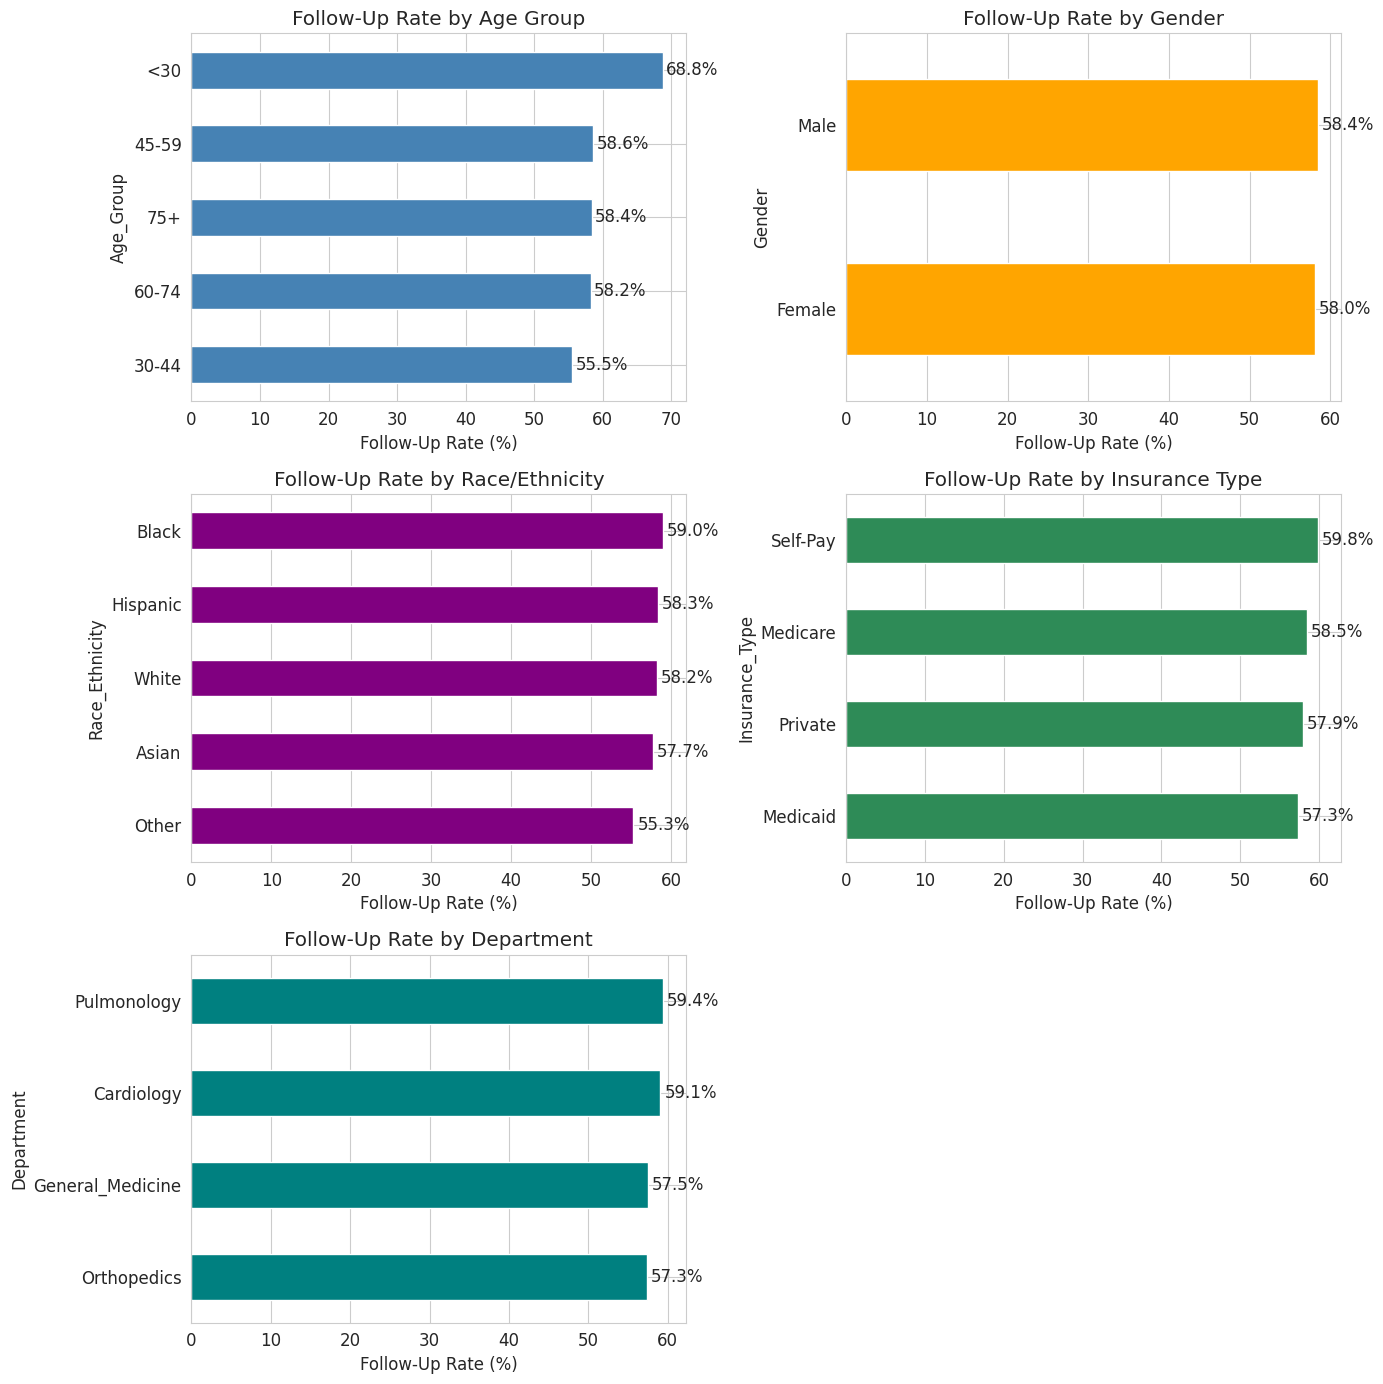

In [60]:
# Compute follow-up rates
age_rates = followup_rate_by("Age_Group")
gender_rates = followup_rate_by("Gender")
race_rates = followup_rate_by("Race_Ethnicity")
insurance_rates = followup_rate_by("Insurance_Type")
dept_rates = followup_rate_by("Department")

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# -----------------------------
# Age Group
# -----------------------------
age_rates.plot(kind="barh", ax=axes[0,0], color="steelblue")
axes[0,0].set_title("Follow-Up Rate by Age Group")
axes[0,0].set_xlabel("Follow-Up Rate (%)")

for i, v in enumerate(age_rates):
    axes[0,0].text(v + 0.5, i, f"{v:.1f}%", va="center")

# -----------------------------
# Gender
# -----------------------------
gender_rates.plot(kind="barh", ax=axes[0,1], color="orange")
axes[0,1].set_title("Follow-Up Rate by Gender")
axes[0,1].set_xlabel("Follow-Up Rate (%)")

for i, v in enumerate(gender_rates):
    axes[0,1].text(v + 0.5, i, f"{v:.1f}%", va="center")

# -----------------------------
# Race/Ethnicity
# -----------------------------
race_rates.plot(kind="barh", ax=axes[1,0], color="purple")
axes[1,0].set_title("Follow-Up Rate by Race/Ethnicity")
axes[1,0].set_xlabel("Follow-Up Rate (%)")

for i, v in enumerate(race_rates):
    axes[1,0].text(v + 0.5, i, f"{v:.1f}%", va="center")

# -----------------------------
# Insurance Type
# -----------------------------
insurance_rates.plot(kind="barh", ax=axes[1,1], color="seagreen")
axes[1,1].set_title("Follow-Up Rate by Insurance Type")
axes[1,1].set_xlabel("Follow-Up Rate (%)")

for i, v in enumerate(insurance_rates):
    axes[1,1].text(v + 0.5, i, f"{v:.1f}%", va="center")

# -----------------------------
# Department
# -----------------------------
dept_rates.plot(kind="barh", ax=axes[2,0], color="teal")
axes[2,0].set_title("Follow-Up Rate by Department")
axes[2,0].set_xlabel("Follow-Up Rate (%)")

for i, v in enumerate(dept_rates):
    axes[2,0].text(v + 0.5, i, f"{v:.1f}%", va="center")

# Remove empty subplot
axes[2,1].axis("off")

plt.tight_layout()
plt.savefig("followup_profile_analysis.png", dpi=150)
plt.show()